# CS 6330 Data Science Project

**Project Title**: Global Aviation Infrastructure Analysis

*   Name: Voleak Lim
*   CID: 81488194
*   Contact: vlim2@angelo.edu
*   GitHub: https://github.com/limvoleak1128/CS-6330-aviation-project

*   Project idea: This project examines how physical infrastructure shapes global air connectivity. Specifically, it investigates whether airport elevation, geographic position, and airport size influence the distance and type of routes an airport can support. Rather than treating aviation purely as
an economic or demand-driven network, this analysis approaches it from
an infrastructure perspective — asking whether the physical characteristics
of an airport constrain or define its role in the global flight network. By integrating airline, airport, and route data, the project applies
regression, classification, and clustering methods to uncover patterns
that predefined labels and conventional assumptions do not fully capture.

# Dataset

- URL: https://www.kaggle.com/datasets/darkmatternet/global-flights-airports-airlines/data?select=airlines.csv
- Description:This dataset integrates three primary aviation files: Airports, Airlines, and Routes. By combining crowdsourced airport and airline data with commercial route information, the dataset provides a comprehensive view of global connectivity, including small regional airfields and inactive carriers.
- Columns and key features:
  1. Airports Table (85,116 rows × 19 columns): elevation_ft, type, continent iso_country, and iata_code
  2. Airlines Table (1,536 rows × 8 columns): callsign, airline_name, and iata_code
  3. Routes Table (66,379 rows × 19 columns): distance_km, airline_name, src_iata, dst_iata, airline_iata, src_country, and dst_country
- Merged Identifiers:  IATA codes used by airlines and airports, including IATA 2-letter and 3-letter codes.

## Project Goals
This project investigates global aviation through five analytical goals:

1. Data Integration: Successfully merge the airlines, airports, and routes
   datasets into a single unified master dataset for analysis.

2. Infrastructure Analysis: Investigate whether source airport elevation
   significantly influences route distance, using latitude and longitude
   as geographic supporting features.

3. Route Type Analysis: Classify routes as domestic or international based on
   geographic and infrastructure features.

4. Traffic Dominance Analysis: Identify the top countries by total inbound
   and outbound flight volume, detect countries where a single airline controls
   more than 70% of routes, and map the most intense continent-to-continent
   traffic corridors.

5. Capacity Analysis: Examine whether medium-sized airports exist that handle
   a disproportionately high number of routes relative to large airports,
   challenging the assumption that airport size determines route capacity.

6. Missing Value Study: Investigate whether empty callsign entries represent
   unrecorded data or airlines that genuinely operate without a callsign.
   **Note**: This goal was set aside during the discovery phase after revealing
   395 missing values, making manual verification impractical. The missing
   values are handled with an 'Unknown' placeholder instead.

This notebook contains the full project analysis, covering data wrangling,
exploration, regression, model performance evaluation, supervised learning,
and unsupervised learning. The necessary libraries are loaded below, along
with the three raw datasets — airlines, airports, and routes — which will
be cleaned and merged into a single master dataset used throughout the analysis.

In [4]:
# ── Standard libraries ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter("ignore")

# ── Visualization ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Patch
from scipy import stats

# ── Scikit-learn: Models ───────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.svm import LinearSVC

# ── Scikit-learn: Preprocessing & Model Selection ─────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.utils import resample

# ── Scikit-learn: Metrics ──────────────────────────────────────────────────
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    log_loss, make_scorer, accuracy_score, silhouette_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

In [5]:
# ── Mount Google Drive to access dataset files stored in Drive ────────────
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# ── Define file paths and load the three raw datasets into dataframes ─────
path1 = '/content/drive/My Drive/CS-6330-aviation-project/dataset/airlines.csv'
path2 = '/content/drive/My Drive/CS-6330-aviation-project/dataset/airports.csv'
path3 = '/content/drive/My Drive/CS-6330-aviation-project/dataset/routes.csv'

df1 = pd.read_csv(path1)   # Airlines dataset
df2 = pd.read_csv(path2)   # Airports dataset
df3 = pd.read_csv(path3)   # Routes dataset

# 1. Exploration

## 1.1 Data Wrangling

### 1.1.1 Data Discovery

I intend to examine the the three source datasets—Airlines, Airports, and Routes denoted as df1, df2, and df3 respectively—to understand their structural dimensions and statistical properties. To quantify the volume of data, .shape attribute will be used and to assess the distribution of numeric values, .describe() will be used. Furthermore, I study on the important features such as callsigns, iata code, airport type, etc applying .count() and .isnull().sum() functions.

In [7]:
print(f"Dataset Dimensions: {df1.shape}")

# Column types and null counts
df1.info()

# Summary statistics (checking for unique IATA codes and active status)
display(df1.describe(include='all'))

# Direct look at the callsign health
print(f"Missing Callsigns: {df1['callsign'].isnull().sum()}")

Dataset Dimensions: (1536, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1536 entries, 0 to 1535
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   airline_id    1536 non-null   int64 
 1   airline_name  1536 non-null   object
 2   alias         1198 non-null   object
 3   iata_code     1534 non-null   object
 4   icao_code     1261 non-null   object
 5   callsign      1141 non-null   object
 6   country       1527 non-null   object
 7   active        1536 non-null   object
dtypes: int64(1), object(7)
memory usage: 96.1+ KB


,airline_id,airline_name,alias,iata_code,icao_code,callsign,country,active
count,1536.000000,1536,1198,1534,1261,1141,1527,1536
unique,NaN,1524,153,1120,1251,1123,202,3
top,NaN,National Airlines,\N,1I,SWR,\N,United States,Y
freq,NaN,3,1046,7,2,3,230,1015
mean,6568.774089,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,6465.912538,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,-1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1881.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,3777.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,10767.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing Callsigns: 395


In [8]:
display(df1.head(10))

,airline_id,airline_name,alias,iata_code,icao_code,callsign,country,active
0,-1,Unknown,\N,-,NaN,\N,\N,Y
1,1,Private flight,\N,-,NaN,NaN,NaN,Y
2,3,1Time Airline,\N,1T,RNX,NEXTIME,South Africa,Y
3,10,40-Mile Air,\N,Q5,MLA,MILE-AIR,United States,Y
4,13,Ansett Australia,\N,AN,AAA,ANSETT,Australia,Y
5,14,Abacus International,\N,1B,NaN,NaN,Singapore,Y
6,15,Abelag Aviation,\N,W9,AAB,ABG,Belgium,N
7,21,Aigle Azur,\N,ZI,AAF,AIGLE AZUR,France,Y
8,22,Aloha Airlines,\N,AQ,AAH,ALOHA,United States,Y
9,24,American Airlines,\N,AA,AAL,AMERICAN,United States,Y


**Interpretation of results**

Initially, I intended to manually verify and fill missing entries for the
callsign column as part of the Missing Value Study goal. However, the
discovery phase revealed 395 missing values, making manual intervention
inefficient and prone to error. As a result, the Missing Value Study goal
is formally dropped, and the missing callsign values are handled with an
'Unknown' placeholder to maintain dataset consistency. This is a deliberate
choice to not overstate findings from incomplete data.

Conversely, the iata_code column showed high data integrity with only 2 missing values, supporting my decision to prioritize this column as the primary key for connecting airline metadata to the global flight routes.

In [9]:
print(f"Dataset Dimensions: {df2.shape}")

# Check for missing coordinates or elevations
df2.info()

# Statistical overview (Check min/max elevation)
display(df2.describe())

# Check unique airport types (large, medium, small)
print("Airport Type Distribution:")
print(df2['type'].value_counts())

Dataset Dimensions: (85116, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85116 entries, 0 to 85115
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 85116 non-null  int64  
 1   ident              85116 non-null  object 
 2   type               85116 non-null  object 
 3   name               85116 non-null  object 
 4   latitude_deg       85116 non-null  float64
 5   longitude_deg      85116 non-null  float64
 6   elevation_ft       70412 non-null  float64
 7   continent          45595 non-null  object 
 8   iso_country        84813 non-null  object 
 9   iso_region         85116 non-null  object 
 10  municipality       80382 non-null  object 
 11  scheduled_service  85116 non-null  object 
 12  icao_code          9891 non-null   object 
 13  iata_code          9062 non-null   object 
 14  gps_code           44092 non-null  object 
 15  local_code         36050 non-null  obj

,id,latitude_deg,longitude_deg,elevation_ft
count,85116.000000,85116.000000,85116.000000,70412.000000
mean,203686.652051,25.812948,-27.438278,1292.845609
std,197939.379404,26.210486,85.334031,1658.178031
min,2.000000,-90.000000,-179.876999,-1266.000000
25%,21435.750000,11.035057,-92.971325,207.000000
50%,45526.500000,35.150824,-64.035593,728.000000
75%,343283.250000,43.067589,23.935567,1608.000000
max,607284.000000,83.091029,179.975700,17372.000000


Airport Type Distribution:
type
small_airport     42562
heliport          22843
closed            13117
medium_airport     4087
seaplane_base      1258
large_airport      1188
balloonport          61
Name: count, dtype: int64


In [10]:
# Create a new column that is True if iata_code is present, False if it is NaN
df2['has_iata'] = df2['iata_code'].notnull()

# Group by 'type' and see the count of valid IATA codes
iata_study = df2.groupby('type').agg(
    total_count=('iata_code', 'size'),
    valid_iata_count=('iata_code', 'count')
)

# Calculate the percentage of validity
iata_study['percent_valid'] = (iata_study['valid_iata_count'] / iata_study['total_count']) * 100

print("IATA Code Availability by Airport Type:")
display(iata_study.sort_values(by='percent_valid', ascending=False))

IATA Code Availability by Airport Type:


,total_count,valid_iata_count,percent_valid
type,,,
large_airport,1188,1182,99.494949
medium_airport,4087,3381,82.725716
seaplane_base,1258,153,12.162162
small_airport,42562,4247,9.978384
heliport,22843,99,0.433393
closed,13117,0,0.000000
balloonport,61,0,0.000000


In [11]:
display(df2.head(5))

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords,has_iata
0,6523,00A,heliport,Total RF Heliport,40.070985,-74.933689,11.0,NaN,US,US-PA,Bensalem,no,NaN,NaN,K00A,00A,https://www.penndot.pa.gov/TravelInPA/airports...,NaN,NaN,False
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435.0,NaN,US,US-KS,Leoti,no,NaN,NaN,00AA,00AA,NaN,NaN,NaN,False
2,6524,00AK,small_airport,Lowell Field,59.947733,-151.692524,450.0,NaN,US,US-AK,Anchor Point,no,NaN,NaN,00AK,00AK,NaN,NaN,NaN,False
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NaN,US,US-AL,Harvest,no,NaN,NaN,00AL,00AL,NaN,NaN,NaN,False
4,506791,00AN,small_airport,Katmai Lodge Airport,59.093287,-156.456699,80.0,NaN,US,US-AK,King Salmon,no,NaN,NaN,00AN,00AN,NaN,NaN,NaN,False


**Interpretation of results**

I observed a significant gap between the total number of airports (55,116) and the 9,062 available IATA codes. By analyzing the data by airport type, I found that large_airport has the highest reliability with a 99.5% IATA valid rate, while types like heliport and closed have almost none. I verified that the name and scheduled_service columns have zero missing values, which is vital for the project because I plan to use these specific columns as the filtering criteria in the next steps.

In [12]:
print(f"Dataset Dimensions: {df3.shape}")

# Check for nulls in airline_iata or equipment
df3.info()

# Summary of flight distances (if already calculated) or equipment types
display(df3.describe(include='all'))

Dataset Dimensions: (66379, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66379 entries, 0 to 66378
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   airline_iata     66379 non-null  object 
 1   airline_name     65529 non-null  object 
 2   airline_country  65529 non-null  object 
 3   src_iata         66379 non-null  object 
 4   src_airport      66379 non-null  object 
 5   src_city         66291 non-null  object 
 6   src_country      66347 non-null  object 
 7   src_lat          66379 non-null  float64
 8   src_lon          66379 non-null  float64
 9   dst_iata         66379 non-null  object 
 10  dst_airport      66379 non-null  object 
 11  dst_city         66291 non-null  object 
 12  dst_country      66347 non-null  object 
 13  dst_lat          66379 non-null  float64
 14  dst_lon          66379 non-null  float64
 15  codeshare        14452 non-null  object 
 16  stops            66379 non

,airline_iata,airline_name,airline_country,src_iata,src_airport,src_city,src_country,src_lat,src_lon,dst_iata,dst_airport,dst_city,dst_country,dst_lat,dst_lon,codeshare,stops,equipment,distance_km
count,66379,65529,65529,66379,66379,66291,66347,66379.000000,66379.000000,66379,66379,66291,66347,66379.000000,66379.000000,14452,66379.000000,66361,66379.000000
unique,564,538,162,3375,3365,3227,229,NaN,NaN,3384,3375,3235,228,NaN,NaN,1,NaN,3881,NaN
top,FR,Ryanair,United States,ATL,Hartsfield Jackson Atlanta International Airport,London,US,NaN,NaN,ATL,Hartsfield Jackson Atlanta International Airport,London,US,NaN,NaN,Y,NaN,320,NaN
freq,2384,2384,14975,915,915,942,13198,NaN,NaN,911,911,939,13193,NaN,NaN,14452,NaN,8972,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.475704,10.720186,NaN,NaN,NaN,NaN,31.462267,10.789673,NaN,0.000166,NaN,1842.560750
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.933868,81.394710,NaN,NaN,NaN,NaN,20.952886,81.422914,NaN,0.012872,NaN,2025.651531
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-54.843300,-179.876999,NaN,NaN,NaN,NaN,-54.843300,-179.876999,NaN,0.000000,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.440966,-73.779317,NaN,NaN,NaN,NaN,24.543889,-73.779317,NaN,0.000000,NaN,616.500000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.083361,9.221960,NaN,NaN,NaN,NaN,36.083361,9.221960,NaN,0.000000,NaN,1184.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.828650,87.479372,NaN,NaN,NaN,NaN,44.828650,87.479372,NaN,0.000000,NaN,2159.000000


In [13]:
display(df3.head(5))

,airline_iata,airline_name,airline_country,src_iata,src_airport,src_city,src_country,src_lat,src_lon,dst_iata,dst_airport,dst_city,dst_country,dst_lat,dst_lon,codeshare,stops,equipment,distance_km
0,2B,Aerocondor,Portugal,AER,Sochi International Airport,Sochi,RU,43.449902,39.956600,KZN,Kazan International Airport,Kazan,RU,55.606201,49.278702,NaN,0,CR2,1507
1,2B,Aerocondor,Portugal,ASF,Astrakhan Narimanovo Boris M. Kustodiev Intern...,Astrakhan,RU,46.282843,48.010511,KZN,Kazan International Airport,Kazan,RU,55.606201,49.278702,NaN,0,CR2,1040
2,2B,Aerocondor,Portugal,ASF,Astrakhan Narimanovo Boris M. Kustodiev Intern...,Astrakhan,RU,46.282843,48.010511,MRV,Mineralnye Vody Airport,Mineralnyye Vody,RU,44.225101,43.081902,NaN,0,CR2,448
3,2B,Aerocondor,Portugal,CEK,Kurchatov Chelyabinsk International Airport,Chelyabinsk,RU,55.303141,61.504927,KZN,Kazan International Airport,Kazan,RU,55.606201,49.278702,NaN,0,CR2,771
4,2B,Aerocondor,Portugal,CEK,Kurchatov Chelyabinsk International Airport,Chelyabinsk,RU,55.303141,61.504927,OVB,Novosibirsk Tolmachevo Airport,Novosibirsk,RU,55.019756,82.618675,NaN,0,CR2,1336


**Interpretation of results**

I discovered that the airline_iata column has zero missing values. However, there are gaps in the airline_name and airline_country columns, which I intend to resolve during the data cleaning phase. Despite these specific missing values, the IATA codes for both the airlines and the airports are in excellent condition. This makes them highly reliable primary keys for merging tables in the upcoming steps.

### 1.1.2 Data Structuring

I standardized the IATA codes across all three datasets to ensure they are Upper Case and Stripped of hidden spaces. The numeric columns revealed a unit inconsistency: airport dataset (df2) provides elevation in feet (elevation_ft), while the routes dataset (df3) focus on kilometers (distance_km) and metric measurements. To maintain scientific consistency across the master dataset, I realized that "Structuring" must include also Unit Standardization.

In [14]:
# Clean up IATA codes for matching
df1['iata_code'] = df1['iata_code'].str.strip().str.upper()
df2['iata_code'] = df2['iata_code'].str.strip().str.upper()
df3['src_iata'] = df3['src_iata'].str.strip().str.upper()
df3['dst_iata'] = df3['dst_iata'].str.strip().str.upper()

# Ensure numeric types for coordinates and distance
df2['latitude_deg'] = pd.to_numeric(df2['latitude_deg'], errors='coerce')
df2['longitude_deg'] = pd.to_numeric(df2['longitude_deg'], errors='coerce')
df3['distance_km'] = pd.to_numeric(df3['distance_km'], errors='coerce')

# Handle Elevation: Convert to numeric, transform to meters, and rename
df2['elevation_ft'] = pd.to_numeric(df2['elevation_ft'], errors='coerce')
df2['elevation_ft'] = df2['elevation_ft'] * 0.3048
df2.rename(columns={'elevation_ft': 'elevation_m'}, inplace=True)

print("Structuring Complete: Formats standardized and elevation converted to meters.")

Structuring Complete: Formats standardized and elevation converted to meters.


**Interpretation of results**

Converting the elevation from feet to meters and renaming the column to elevation_m eliminated unit confusion and aligned the vertical measurements with the metric horizontal measurements (distance_km). using meters for elevation provides a more precise and readable integer for altitude, because if km is to be used on elevation, elevation would result in tiny, awkward decimals which will be hard to read.

### 1.1.3 Data Cleaning

df1 is to be refined to only contain of active operational airline information. First, I will filter the dataset to include only Active Airlines, as inactive entities would skew modern flight analysis. Second, I will remove records where the airline name is a generic "Unknown" placeholder to eliminate noise. Moreover, callsign missing value will be studied to identify the geographic distribution of these gaps and then use imputation to replace all remaining null values with a standardized "Unknown" label.

The missing value in this project is denoted by "Unknown", because for NA is to be used to present the actual value that actually has meaning.

In [15]:
# Filter for Active Airlines
df1_active = df1[df1['active'] == 'Y'].copy()

# Remove the "Unknown" placeholder (cleaning the noise)
df1_active = df1_active[df1_active['airline_name'].str.lower() != 'unknown']

# THE CALLSIGN STUDY (Automated Audit)
null_callsigns = df1_active[df1_active['callsign'].isnull()]

print(f"Total Active Airlines: {len(df1_active)}")
print(f"Number of Active Airlines with Null Callsigns: {len(null_callsigns)}")

# Instead of manual checking, look at the top 10 countries with missing callsigns
print("\nTop 10 Countries with Missing Callsigns:")
display(null_callsigns['country'].value_counts().head(10))

# Impute the nulls with 'UNKNOWN'
df1_active['callsign'] = df1_active['callsign'].fillna('Unknown')


Total Active Airlines: 1014
Number of Active Airlines with Null Callsigns: 242

Top 10 Countries with Missing Callsigns:


,count
country,
United States,27
Russia,15
Australia,11
Germany,10
Brazil,10
Spain,8
Argentina,7
Canada,7
Italy,6


**Interpretation of results**

The callsign audit revealed that missing data is not random but often concentrated within specific countries (such as the United States or Russia), suggesting regional differences in data reporting. By imputing 242 null values with a standardized "Unknown" string, I have eliminated all nulls in the callsign column.

In [16]:
df1_active.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1014 entries, 1 to 1535
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   airline_id    1014 non-null   int64 
 1   airline_name  1014 non-null   object
 2   alias         759 non-null    object
 3   iata_code     1013 non-null   object
 4   icao_code     852 non-null    object
 5   callsign      1014 non-null   object
 6   country       1012 non-null   object
 7   active        1014 non-null   object
dtypes: int64(1), object(7)
memory usage: 71.3+ KB


After filtering, I discovered that there remain only one missing value for iata_code for airlines data. Because this column serves as the primary key for the merging, losing this row would result in the loss of all flight routes associated with this carrier, therefore I will manually research and insert the correct iata code for this specific record.

In [17]:
display(df1_active[df1_active['iata_code'].isnull()])

,airline_id,airline_name,alias,iata_code,icao_code,callsign,country,active
1210,13190,Al-Naser Airlines,NaN,NaN,NaN,Unknown,Iraq,Y


In [18]:
df1_active.loc[df1_active['airline_name'] == 'Al-Naser Airlines', 'iata_code'] = '6N'
display(df1_active[df1_active['iata_code'] == '6N'])

,airline_id,airline_name,alias,iata_code,icao_code,callsign,country,active
1210,13190,Al-Naser Airlines,NaN,6N,NaN,Unknown,Iraq,Y


**Interpretation of results**

By isolating the single null entry to find the name of the airline first, and then manually search for the iata_code for that specific airlines and imputing the '6N' code for Al-Naser Airlines.

I intend to clean the Airports dataset by narrowing the scope to operational, commercial facilities. First, I will remove all airports marked as "closed" to ensure the analysis reflects the current physical infrastructure available for travel. Second, I will filter the data to retain only those airports that support scheduled commercial service, as these are the only sites relevant to a routes-based study. Finally, I will address missing values in the elevation_m column. Rather than using a global average, I will apply Group-Based Median Imputation by calculating the median elevation for each specific airport type (e.g., large vs. small) and fill gaps with those values.

In [19]:
# Filter for operational airports only to remove closed sites
df2_clean = df2[df2['type'] != 'closed'].copy()

# Keep only airports that support scheduled commercial services
df2_clean = df2_clean[df2_clean['scheduled_service'] == 'yes']

# Calculate the median elevation for each airport type
type_medians = df2_clean.groupby('type')['elevation_m'].transform('median')
# Fill the missing elevation values using the medians of their respective groups
df2_clean['elevation_m'] = df2_clean['elevation_m'].fillna(type_medians)

I intend to analyze the IATA identifier's distribution across different airport categories. To do this, I will create a boolean feature, has_iata, to distinguish between airports with valid codes and those without. By calculating the percentage of "IATA presence" for each airport type, I can quantitatively verify the reliability of my primary keys. Finally, I will fill any remaining null values in the iata_code column with a standardized "Unknown" string to ensure that the column maintains a consistent string data type, preventing technical errors during the final merge.

In [20]:
# Create a summary table showing IATA presence by airport type
iata_analysis = df2_clean.groupby('type')['has_iata'].value_counts().unstack().fillna(0)

# Calculate the percentage of airports that have an IATA code for each type
iata_analysis['%_has_iata'] = (iata_analysis[True] / (iata_analysis[True] + iata_analysis[False])) * 100

# Display the summary
print("IATA Code Presence by Airport Type:")
display(iata_analysis)

# Impute missing IATA codes with 'NA' to ensure string consistency
df2_clean['iata_code'] = df2_clean['iata_code'].fillna('Unknown')

IATA Code Presence by Airport Type:


has_iata,False,True,%_has_iata
type,,,
heliport,48,54,52.941176
large_airport,4,1161,99.656652
medium_airport,28,2109,98.689752
seaplane_base,18,71,79.775281
small_airport,142,780,84.598698


**Interpretation of results**

Large Airports show a 99.6% IATA valid rate, and Medium Airports show 98.6%. Since these two categories handle the vast majority of global commercial traffic, this result proves that the primary keys needed for merging are almost entirely intact. Conversely, the low IATA presence in categories like Heliports (2.9%) and Seaplane Bases (9.7%) confirms that these sites rarely participate in the international IATA routing system. By identifying this, I can confidently proceed with the merge, knowing that any "Unknown" placeholders will be confined to minor transit points and will not compromise the integrity of the major flight paths being studied.

I intend to resolve a critical parsing error regarding the continent column in the Airports dataset. Cross-referencing with the original data source revealed that the dataset uses two-letter codes, where 'NA' represents North America. However, during the initial data load, these values were incorrectly interpreted as "Not Available" (nulls). I will first replace these erroneous nulls with the correct 'NA' string. Subsequently, to improve the clarity of the dataset for the final analysis and reporting phase, I will map all two-letter continent codes to their full geographic names (e.g., 'AS' to 'Asia').

In [21]:
# Replace the incorrectly parsed nulls with the string 'NA' (North America)
df2_clean['continent'] = df2_clean['continent'].fillna('NA')

# Display unique continent codes
print("Confirmed Continent Codes:", df2_clean['continent'].unique())

Confirmed Continent Codes: ['OC' 'NA' 'AS' 'EU' 'SA' 'AF' 'AN']


In [22]:
# Define a mapping dictionary for clarity
continent_mapping = {
    'AF': 'Africa',
    'AN': 'Antarctica',
    'AS': 'Asia',
    'EU': 'Europe',
    'NA': 'North America',
    'OC': 'Oceania',
    'SA': 'South America'
}

# Apply the mapping to the continent column
df2_clean['continent'] = df2_clean['continent'].map(continent_mapping)

In [23]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66379 entries, 0 to 66378
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   airline_iata     66379 non-null  object 
 1   airline_name     65529 non-null  object 
 2   airline_country  65529 non-null  object 
 3   src_iata         66379 non-null  object 
 4   src_airport      66379 non-null  object 
 5   src_city         66291 non-null  object 
 6   src_country      66347 non-null  object 
 7   src_lat          66379 non-null  float64
 8   src_lon          66379 non-null  float64
 9   dst_iata         66379 non-null  object 
 10  dst_airport      66379 non-null  object 
 11  dst_city         66291 non-null  object 
 12  dst_country      66347 non-null  object 
 13  dst_lat          66379 non-null  float64
 14  dst_lon          66379 non-null  float64
 15  codeshare        14452 non-null  object 
 16  stops            66379 non-null  int64  
 17  equipment   

**Interpretation of results**

The successful recovery of the North American continent data was a pivotal step in maintaining the global integrity of the project. I prevented the unintentional exclusion of an entire geographic region. Converting the codes to full names like "North America" and "Oceania" removes ambiguity and prepares the dataset for the next phase of the study that needs continents data.

I intend to perform a cross-reference audit between the Routes dataset (df3) and the cleaned Airline master list (df1_active). During the discovery phase, I noticed that several rows in the Routes table were missing the airline_name, even though they had an airline_iata code. I will extract these unique "orphan" codes and search for them in my cleaned airline database.

In [24]:
# Print the number of missing rows and display them
print(f"Total rows with null airline_name: {len(df3[df3['airline_name'].isnull()])}")

# Get the unique codes from the rows where the name is missing
missing_names_codes = df3[df3['airline_name'].isnull()]['airline_iata'].unique()

# 2. Check which of these codes actually exist in our cleaned df1_active
found_in_df1 = df1_active[df1_active['iata_code'].isin(missing_names_codes)]

# 3. Report the findings
print(f"Unique codes with missing names in df3: {missing_names_codes}")
print(f"Number of these codes found in df1_active: {len(found_in_df1)}")

if len(found_in_df1) > 0:
    print("Matches found! We can recover these names:")
    display(found_in_df1[['iata_code', 'airline_name']])
else:
    print("No matches found. These codes do not exist in our Airline master list.")

Total rows with null airline_name: 850
Unique codes with missing names in df3: ['3H' '4E' '4W' '5U' '6L' '7S' '9D' '9M' 'ABJ' 'EB' 'HS' 'IOS' 'NHG' 'O4'
 'P1' 'P2' 'P6' 'PB' 'TCX' 'TOM' 'WT' 'X4' 'XU' 'YJ' 'YN' 'ZD']
Number of these codes found in df1_active: 0
No matches found. These codes do not exist in our Airline master list.


**Interpretation of results**

The cross-reference audit revealed that there are 850 rows in the Routes dataset with missing airline names, corresponding to 26 unique IATA codes. My investigation showed that zero (0) of these codes exist within the df1_active master list. This result is significant because it confirms that the missing data is due to a "Source Gap"—the reference dataset simply does not contain these specific carriers.

I intend to analyze the relationship between missing values in the airline_name and airline_country columns. Specifically, I will test for null-value correlation to see if rows missing a name are also missing a country. This "Double-Check" is necessary to determine the extent of the data gap: if both are missing, it confirms that the entire airline profile is absent from the source. This audit provides the final justification for using a blanket "Unknown" imputation

In [25]:
# Check if Name and Country are missing in the same rows
null_name = df3['airline_name'].isnull()
null_country = df3['airline_country'].isnull()

# Count how many rows have both missing
correlated_nulls = df3[null_name & null_country].shape[0]

print(f"Rows missing airline_name: {null_name.sum()}")
print(f"Rows missing airline_country: {null_country.sum()}")
print(f"Rows missing BOTH: {correlated_nulls}")

Rows missing airline_name: 850
Rows missing airline_country: 850
Rows missing BOTH: 850


In [26]:
# Imputation: Replace nulls with 'Unknown' placeholder
df3_clean = df3.copy()
df3_clean['airline_name'] = df3_clean['airline_name'].fillna('Unknown')
df3_clean['airline_country'] = df3_clean['airline_country'].fillna('Unknown')
df3_clean['src_city'] = df3_clean['src_city'].fillna('Unknown')
df3_clean['dst_city'] = df3_clean['dst_city'].fillna('Unknown')
df3_clean['equipment'] = df3_clean['equipment'].fillna('Unknown')

**Interpretation of results**

Upon auditing the dataset, I confirmed that airline_name and airline_country are indeed missing at the same time for certain records. However, I have decided to label these as "Unknown" instead of dropping the entire row. My reasoning is that preserving these 850 data points is vital, as they still contribute significantly to the project's overall analysis.

While some metadata—such as the specific aircraft type (equipment) or city names—is missing for a small fraction of records, the critical spatial data (latitudes, longitudes, and distances) remains fully intact. By choosing to impute these gaps with "Unknown," I am able to keep the route information in the study

In the ISO 3166-1 alpha-2 standard, "NA" is the official country code for Namibia. However, similar to the continent data, these codes were incorrectly read as "Not Available" (null) during the data import process.

In [27]:
# Restore Namibia's country code
# NOTE: 'NA' is the ISO 3166-1 alpha-2 code for Namibia, not a missing value.
df3_clean['src_country'] = df3_clean['src_country'].fillna('NA')
df3_clean['dst_country'] = df3_clean['dst_country'].fillna('NA')

I intend to streamline all three dataframes by dropping redundant or irrelevant columns before the final merge. In the Airlines dataset, I am removing alias and icao_code. In the Airports dataset, I am stripping away administrative metadata—such as home_link, wikipedia_link, and keywords—which do not contribute to geographic or distance analysis. Finally, in the Routes dataset, I am dropping codeshare flag.

In [28]:
# Dropping irelevant columns from dataframe

df1_active = df1_active.drop(columns=['alias', 'icao_code'], errors='ignore')

df2_cols_to_drop = [
    'home_link', 'wikipedia_link', 'keywords',
    'local_code', 'gps_code', 'icao_code', 'scheduled_service'
]
df2_clean = df2_clean.drop(columns=df2_cols_to_drop, errors='ignore')

df3_cols_to_drop = ['codeshare']
df3_clean = df3_clean.drop(columns=df3_cols_to_drop, errors='ignore')

In [29]:
df3_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66379 entries, 0 to 66378
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   airline_iata     66379 non-null  object 
 1   airline_name     66379 non-null  object 
 2   airline_country  66379 non-null  object 
 3   src_iata         66379 non-null  object 
 4   src_airport      66379 non-null  object 
 5   src_city         66379 non-null  object 
 6   src_country      66379 non-null  object 
 7   src_lat          66379 non-null  float64
 8   src_lon          66379 non-null  float64
 9   dst_iata         66379 non-null  object 
 10  dst_airport      66379 non-null  object 
 11  dst_city         66379 non-null  object 
 12  dst_country      66379 non-null  object 
 13  dst_lat          66379 non-null  float64
 14  dst_lon          66379 non-null  float64
 15  stops            66379 non-null  int64  
 16  equipment        66379 non-null  object 
 17  distance_km 

### 1.1.4 Data Enriching

**Project Goal**: Data Integration: Successfully merge the airlines, airports, and routes datasets into a single unified master dataset for analysis

I intend to create a comprehensive master dataset by merging the cleaned
Routes dataframe with the Airlines and Airports reference tables. From the
Airlines dataset, the callsign column is merged in as a supplementary
identifier that links each route to its operating airline. While callsign
is not directly used in the subsequent analyses, it was retained as part
of the enrichment process to keep the master dataset as complete as possible

To ensure a perfect "one-to-one" match and maintain the original row count of 66,379, I will first deduplicate the IATA codes in the reference datasets. I will then perform a series of "Left Joins" to pull in specific features: the airline callsign, and the continent, airport_type, and elevation_m for both the source and destination airports.

In [30]:
# We keep the first occurrence of any duplicate IATA code
df1_unique = df1_active.drop_duplicates(subset=['iata_code'], keep='first')
df2_unique = df2_clean.drop_duplicates(subset=['iata_code'], keep='first')

In [31]:
# 1. Merge with Airlines for 'callsign'
master_df = df3_clean.merge(
    df1_unique[['iata_code', 'callsign']],
    left_on='airline_iata',
    right_on='iata_code',
    how='left'
).drop(columns=['iata_code'], errors='ignore')

# 2. Merge for DEPARTURE info
master_df = master_df.merge(
    df2_unique[['iata_code', 'continent', 'type', 'elevation_m']].rename(columns={
        'continent': 'src_continent',
        'type': 'src_airport_type',
        'elevation_m': 'src_elevation'
    }),
    left_on='src_iata',
    right_on='iata_code',
    how='left'
).drop(columns=['iata_code'], errors='ignore')

# 3. Merge for DESTINATION info
master_df = master_df.merge(
    df2_clean[['iata_code', 'continent', 'type', 'elevation_m']].rename(columns={
        'continent': 'dst_continent',
        'type': 'dst_airport_type',
        'elevation_m': 'dst_elevation'
    }),
    left_on='dst_iata',
    right_on='iata_code',
    how='left'
).drop(columns=['iata_code'], errors='ignore')

# Check the final column list
print("Clear Master Columns:")
print(master_df.columns.tolist())

Clear Master Columns:
['airline_iata', 'airline_name', 'airline_country', 'src_iata', 'src_airport', 'src_city', 'src_country', 'src_lat', 'src_lon', 'dst_iata', 'dst_airport', 'dst_city', 'dst_country', 'dst_lat', 'dst_lon', 'stops', 'equipment', 'distance_km', 'callsign', 'src_continent', 'src_airport_type', 'src_elevation', 'dst_continent', 'dst_airport_type', 'dst_elevation']


**Interpretation of results**

The successful creation of the master_df marks the transition from data cleaning to Data Enrichment. Each row in the dataset now represents a "Complete Story": we no longer just see a route code; we see the airline's callsign, the type of airports involved (e.g., Large vs. Medium), and the specific environmental context (elevation and continent) of both the departure and arrival points. The column list is now clean and intuitive, with clearly labeled "src" and "dst" prefixes.

In [32]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66379 entries, 0 to 66378
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   airline_iata      66379 non-null  object 
 1   airline_name      66379 non-null  object 
 2   airline_country   66379 non-null  object 
 3   src_iata          66379 non-null  object 
 4   src_airport       66379 non-null  object 
 5   src_city          66379 non-null  object 
 6   src_country       66379 non-null  object 
 7   src_lat           66379 non-null  float64
 8   src_lon           66379 non-null  float64
 9   dst_iata          66379 non-null  object 
 10  dst_airport       66379 non-null  object 
 11  dst_city          66379 non-null  object 
 12  dst_country       66379 non-null  object 
 13  dst_lat           66379 non-null  float64
 14  dst_lon           66379 non-null  float64
 15  stops             66379 non-null  int64  
 16  equipment         66379 non-null  object

**Interpretation of results**

The .info() output confirms that the master dataframe has maintained the original 66,379 records, proving that the deduplication of keys was successful. We observe that the new columns (like src_continent and callsign) have slightly lower non-null counts than the core route data. This indicates that approximately 1–2% of the IATA codes in the routes dataset do not have corresponding entries in the global airline or airport master lists. This is a common occurrence in aviation data due to small private airstrips or retired codes. However, with over 98% data coverage across all 21 columns, the dataset is now sufficiently enriched for high-level geographic and distance analysis.

I will apply the "Unknown" placeholder to any missing callsigns to maintain string consistency. Second, I will handle missing elevation data using Geographic Group-Based Imputation. Instead of using a global average, I will calculate the median elevation for each specific country and fill the gaps accordingly. Finally, for any countries that lack elevation data entirely, I will apply a zero-fill as a technical fail-safe.

In [33]:
# Fill missing callsigns with a placeholder
master_df['callsign'] = master_df['callsign'].fillna('Unknown')

# I mputation: Fill missing elevation using the Country Median
# We group by country and fill the 'NaN' with that country's median elevation
master_df['src_elevation'] = master_df.groupby('src_country')['src_elevation'].transform(lambda x: x.fillna(x.median()))
master_df['dst_elevation'] = master_df.groupby('dst_country')['dst_elevation'].transform(lambda x: x.fillna(x.median()))

# Cleanup of any remaining numeric nulls (if a country has NO elevation data at all)
master_df['src_elevation'] = master_df['src_elevation'].fillna(0)
master_df['dst_elevation'] = master_df['dst_elevation'].fillna(0)

I intend to execute a secondary recovery phase to fill gaps in continent and airport type data that persisted after the initial merge. First, I will create a Continent-to-Country Lookup to map missing continents based on the known country codes. Second, I will perform a String-Normalized Name Lookup: by stripping and lowering the case of airport names in both the master list and the reference list, I can match records based on their text descriptions even if their IATA codes were missing or mismatched. Finally, I will apply a terminal "Unknown" placeholder to any remaining gaps to ensure 100% column density, followed by a cleanup of temporary processing columns to maintain a lean dataset.

In [34]:
# Create the continent lookup from the country code
continent_lookup = df2_clean.set_index('iso_country')['continent'].to_dict()

# Fill missing continent gaps using the country map
master_df['src_continent'] = master_df['src_continent'].fillna(master_df['src_country'].map(continent_lookup))
master_df['dst_continent'] = master_df['dst_continent'].fillna(master_df['dst_country'].map(continent_lookup))

# Standardize names in both DataFrames to ensure string consistency for the type lookup
df2_clean['name_clean'] = df2_clean['name'].str.lower().str.strip()
master_df['src_airport_clean'] = master_df['src_airport'].str.lower().str.strip()
master_df['dst_airport_clean'] = master_df['dst_airport'].str.lower().str.strip()

# Create the type lookup using the cleaned names
type_lookup = df2_clean.set_index('name_clean')['type'].to_dict()

# Fill missing airport type gaps using the cleaned name map
master_df['src_airport_type'] = master_df['src_airport_type'].fillna(master_df['src_airport_clean'].map(type_lookup))
master_df['dst_airport_type'] = master_df['dst_airport_type'].fillna(master_df['dst_airport_clean'].map(type_lookup))

# Final safety net: Fill any remaining nulls in these four columns with 'Unknown'
master_df['src_continent'] = master_df['src_continent'].fillna('Unknown')
master_df['dst_continent'] = master_df['dst_continent'].fillna('Unknown')
master_df['src_airport_type'] = master_df['src_airport_type'].fillna('Unknown')
master_df['dst_airport_type'] = master_df['dst_airport_type'].fillna('Unknown')

# Remove temporary columns used for cleaning
master_df.drop(columns=['src_airport_clean', 'dst_airport_clean'], inplace=True)

# Final audit of the recovered columns
print("Remaining nulls after recovery:")
print(master_df[['src_continent', 'dst_continent', 'src_airport_type', 'dst_airport_type']].isnull().sum())

Remaining nulls after recovery:
src_continent       0
dst_continent       0
src_airport_type    0
dst_airport_type    0
dtype: int64


**Interpretation of Results**

The implementation of "Backup Lookups" has significantly increased the depth of the master dataset. By utilizing country-level and name-level associations, I have successfully "recovered" metadata for airports that were initially orphaned during the IATA-based merge. his high level of data completeness ensures that our continent-based and airport-type-based analyses will be based on the maximum possible sample size, providing a truly global perspective.

In [35]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66379 entries, 0 to 66378
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   airline_iata      66379 non-null  object 
 1   airline_name      66379 non-null  object 
 2   airline_country   66379 non-null  object 
 3   src_iata          66379 non-null  object 
 4   src_airport       66379 non-null  object 
 5   src_city          66379 non-null  object 
 6   src_country       66379 non-null  object 
 7   src_lat           66379 non-null  float64
 8   src_lon           66379 non-null  float64
 9   dst_iata          66379 non-null  object 
 10  dst_airport       66379 non-null  object 
 11  dst_city          66379 non-null  object 
 12  dst_country       66379 non-null  object 
 13  dst_lat           66379 non-null  float64
 14  dst_lon           66379 non-null  float64
 15  stops             66379 non-null  int64  
 16  equipment         66379 non-null  object

**Interpretation of Results**

The final structure of the master_df represents the successful culmination of the data cleaning and enrichment phase. We have scaled the dataset to 66,379 records with zero missing values across all 21 analytical features.

### 1.1.5 Data Validating

I will perform a redundancy check by identifying and removing any duplicate records that may have surfaced during the multi-stage merging process, ensuring that flight volumes are not artificially inflated. Following this, I will execute a physical feasibility check to flag "0 km" or less flights; these records often represent data entry errors or identical source and destination points that would skew distance-based calculations.

In [36]:
# Check for and remove duplicate records
initial_count = len(master_df)
master_df = master_df.drop_duplicates()
duplicates_removed = initial_count - len(master_df)

# Check for distance anomalies (0 km flights or negatives)
zero_dist_flights = master_df[master_df['distance_km'] <= 0].shape[0]

# Check for statistical outliers in distance using a boxplot summary
distance_stats = master_df['distance_km'].describe()

print(f"Duplicates removed: {duplicates_removed}")
print(f"Flights with 0 distance found: {zero_dist_flights}")
print("\nDistance Statistics (km):")
print(distance_stats)

Duplicates removed: 0
Flights with 0 distance found: 1

Distance Statistics (km):
count    66379.000000
mean      1842.560750
std       2025.651531
min          0.000000
25%        616.500000
50%       1184.000000
75%       2159.000000
max      13808.000000
Name: distance_km, dtype: float64


I intend to isolate and remove any physically impossible data points where the recorded flight distance is exactly 0 kilometers since the min distance_km is 0 according to the statisitc above. By first extracting these specific records for inspection, I can determine if they represent administrative errors, test data, or instances where the source and destination coordinates were identical.

In [37]:
# Isolate the zero-distance row(s) to see the details
zero_dist_rows = master_df[master_df['distance_km'] == 0]

# Print the specific rows for inspection
print("Rows with 0 km distance:")
display(zero_dist_rows)

# Remove the zero-distance rows from the master dataset
master_df = master_df[master_df['distance_km'] > 0]

# Confirm the new count and verify the minimum distance is now above zero
print(f"\nFinal count after removing anomalies: {len(master_df)}")
print(f"New minimum distance: {master_df['distance_km'].min()} km")

Rows with 0 km distance:


,airline_iata,airline_name,airline_country,src_iata,src_airport,src_city,src_country,src_lat,src_lon,dst_iata,...,stops,equipment,distance_km,callsign,src_continent,src_airport_type,src_elevation,dst_continent,dst_airport_type,dst_elevation
32602,IL,Fly Illi,United States,PKN,Iskandar Airport,Pangkalanbun,ID,-2.7052,111.672997,PKN,...,0,AT7,0,Unknown,Asia,small_airport,22.86,Asia,small_airport,22.86



Final count after removing anomalies: 66378
New minimum distance: 3 km


**Interpretation of Results**

The detailed inspection of the 0 km records confirmed a logical error in the source data: these rows represented "flights" where the departure and destination were identical—the same airport, city, and country. Since a commercial flight route by definition requires transit between two distinct points, these records were physically impossible and had to be removed to maintain the study's integrity.

Following this filter, the new minimum flight distance was recorded at 3 km. Unlike the 0 km records, this value is highly plausible within the context of this dataset. Given that our "Airport Type" audit confirmed the presence of Seaplane Bases and Small Airports, a 3 km distance represents short-range shuttle services or inter-island hops that are common in specific geographic regions.

### 1.1.6 Publishing

I intend to finalize the dataset by implementing a logical schema reordering and exporting the result for permanent storage. This organizational step ensures that the CSV is "human-readable" and user-friendly for future stakeholders. Once the structure is optimized, I will publish the master_df to a dedicated directory in Google Drive, ensuring that the cleaned, validated, and enriched data is safely archived and ready for the reporting phase.

In [38]:
# Define the new logical order for the columns
new_order = [
    # Airline Info
    'airline_iata', 'airline_name', 'callsign', 'airline_country',

    # Source Info
    'src_iata', 'src_airport', 'src_city', 'src_country',
    'src_lat', 'src_lon', 'src_continent', 'src_airport_type',
    'src_elevation',

    # Destination Info
    'dst_iata', 'dst_airport', 'dst_city', 'dst_country',
    'dst_lat', 'dst_lon', 'dst_continent', 'dst_airport_type',
    'dst_elevation',

    # Route Specifics
    'stops', 'equipment', 'distance_km'
]

# Apply the new order to the dataframe
master_df = master_df[new_order]

In [39]:
# Define the path to your specific Google Drive folder
save_path = '/content/drive/My Drive/CS-6330-aviation-project/dataset/final_cleaned_flight_data.csv'

# Save the master_df directly to that folder
master_df.to_csv(save_path, index=False)

print(f"The file is now saved in your Google Drive at: {save_path}")

The file is now saved in your Google Drive at: /content/drive/My Drive/CS-6330-aviation-project/dataset/final_cleaned_flight_data.csv


**Interpretation of Results**

The publication of the final_cleaned_flight_data.csv represents the successful completion of the Data Engineering lifecycle.

## 1.2 Data Exploration

### 1.2.1 Data Understanding & Summary

#### 📊 Data Dictionary: Flight Route Analysis
This dataset contains merged information from airline, airport, and route databases.
It provides a comprehensive view of global flight connectivity, including geographic
coordinates and calculated distances.

---

### 🏢 Airline Information
| Column Name | Description |
| :--- | :--- |
| **airline_iata** | Two-letter IATA code of the operating airline (e.g., `BA`, `SQ`). |
| **airline_name** | Full legal name of the operating airline. |
| **callsign** | Airline radio callsign used in air traffic control. |
| **airline_country** | The primary country where the airline is registered. |

### 🛫 Departure (Source) Details
| Column Name | Description |
| :--- | :--- |
| **src_iata** | 3-letter IATA code of the departure airport. |
| **src_airport** | Full official name of the origin airport. |
| **src_city** | City served by the departure airport. |
| **src_country** | Country where the departure airport is located. |
| **src_continent** | Continent where the departure airport is located. |
| **src_airport_type** | Type of airport the departure airport is located. |
| **src_elevation** | departure airport elevation above mean sea level in meter. |

### 🛬 Arrival (Destination) Details
| Column Name | Description |
| :--- | :--- |
| **dst_iata** | 3-letter IATA code of the destination airport. |
| **dst_airport** | Full official name of the destination airport. |
| **dst_city** | City served by the destination airport. |
| **dst_country** | Country where the destination airport is located. |
| **dst_continent** | Continent where the destination airport is located. |
| **dst_airport_type** | Type of airport the destination airport is located. |
| **dst_elevation** | destination airport elevation above mean sea level in meter. |

### 🛠️ Flight Technicals & Metrics
| Column Name | Description |
| :--- | :--- |
| **stops** | Number of intermediate stops (0 for direct flights). |
| **distance_km** | Calculated Great-circle distance between airports using the Haversine formula. |


I will begin the exploration by identifying the dimensions and data types of the master_df. I will categorize the 21 features into numerical and categorical groups. For the numerical features, I will specifically calculate and display their ranges, formatting the elevation data to three decimal places for precision. For the categorical features, I will distinguish between those with a small number of groups and high-cardinality identifiers.

In [40]:
# Shape of the dataset
print(f"Dataset Dimensions: {master_df.shape}")

# Identify Numerical and Categorical columns
numerical_cols = master_df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = master_df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical Features: {numerical_cols}")
print(f"Categorical Features: {categorical_cols}")

# List Ranges for Numerical Features with specific formatting
print("\n--- Numerical Ranges ---")
for col in numerical_cols:
    col_min = master_df[col].min()
    col_max = master_df[col].max()

    # Format elevation with 3 decimal places, others as integers/standard
    if 'elevation' in col:
        print(f"{col:<18} | Range: {col_min:>10.3f} to {col_max:>10.3f}")
    else:
        print(f"{col:<18} | Range: {col_min:>10} to {col_max:>10}")

# List Category Values/Counts for Categorical Features
print("\n--- Categorical Values ---")
for col in categorical_cols:
    unique_count = master_df[col].nunique()
    if unique_count < 10:
        values = master_df[col].unique()
        print(f"{col:<18} | {unique_count} categories: {values}")
    else:
        print(f"{col:<18} | {unique_count:>5} unique categories (High Cardinality)")

# Full Summary Table
display(master_df.describe(include='all'))

Dataset Dimensions: (66378, 25)

Numerical Features: ['src_lat', 'src_lon', 'src_elevation', 'dst_lat', 'dst_lon', 'dst_elevation', 'stops', 'distance_km']
Categorical Features: ['airline_iata', 'airline_name', 'callsign', 'airline_country', 'src_iata', 'src_airport', 'src_city', 'src_country', 'src_continent', 'src_airport_type', 'dst_iata', 'dst_airport', 'dst_city', 'dst_country', 'dst_continent', 'dst_airport_type', 'equipment']

--- Numerical Ranges ---
src_lat            | Range:   -54.8433 to  78.246101
src_lon            | Range: -179.876999 to 179.340587
src_elevation      | Range:    -21.946 to   4411.066
dst_lat            | Range:   -54.8433 to  78.246101
dst_lon            | Range: -179.876999 to 179.340587
dst_elevation      | Range:    -21.946 to   4411.066
stops              | Range:          0 to          1
distance_km        | Range:          3 to      13808

--- Categorical Values ---
airline_iata       |   564 unique categories (High Cardinality)
airline_name       

,airline_iata,airline_name,callsign,airline_country,src_iata,src_airport,src_city,src_country,src_lat,src_lon,...,dst_city,dst_country,dst_lat,dst_lon,dst_continent,dst_airport_type,dst_elevation,stops,equipment,distance_km
count,66378,66378,66378,66378,66378,66378,66378,66378,66378.000000,66378.000000,...,66378,66378,66378.000000,66378.000000,66378,66378,66378.000000,66378.000000,66378,66378.000000
unique,564,539,429,163,3375,3365,3228,230,NaN,NaN,...,3236,229,NaN,NaN,6,6,NaN,NaN,3882,NaN
top,FR,Ryanair,Unknown,United States,ATL,Hartsfield Jackson Atlanta International Airport,London,US,NaN,NaN,...,London,US,NaN,NaN,Asia,large_airport,NaN,NaN,320,NaN
freq,2384,2384,4664,14974,915,915,942,13198,NaN,NaN,...,939,13193,NaN,NaN,21397,56962,NaN,NaN,8972,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.476219,10.718665,...,NaN,NaN,31.462782,10.788153,NaN,NaN,233.397661,0.000166,NaN,1842.588508
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.933606,81.394380,...,NaN,NaN,20.952624,81.422586,NaN,NaN,454.103476,0.012872,NaN,2025.654164
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-54.843300,-179.876999,...,NaN,NaN,-54.843300,-179.876999,NaN,NaN,-21.945600,0.000000,NaN,3.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.440966,-73.779317,...,NaN,NaN,24.543889,-73.779317,NaN,NaN,10.972800,0.000000,NaN,617.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.083361,9.221960,...,NaN,NaN,36.083361,9.221960,NaN,NaN,53.949600,0.000000,NaN,1184.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.828650,87.479372,...,NaN,NaN,44.828650,87.479372,NaN,NaN,208.788000,0.000000,NaN,2159.000000


In [41]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66378 entries, 0 to 66378
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   airline_iata      66378 non-null  object 
 1   airline_name      66378 non-null  object 
 2   callsign          66378 non-null  object 
 3   airline_country   66378 non-null  object 
 4   src_iata          66378 non-null  object 
 5   src_airport       66378 non-null  object 
 6   src_city          66378 non-null  object 
 7   src_country       66378 non-null  object 
 8   src_lat           66378 non-null  float64
 9   src_lon           66378 non-null  float64
 10  src_continent     66378 non-null  object 
 11  src_airport_type  66378 non-null  object 
 12  src_elevation     66378 non-null  float64
 13  dst_iata          66378 non-null  object 
 14  dst_airport       66378 non-null  object 
 15  dst_city          66378 non-null  object 
 16  dst_country       66378 non-null  object 
 17

**Interpretation of Results**

The dataset contains 66,378 rows and 21 columns, providing a massive sample size for analysis.

The Numerical Ranges show a wide variation in flight logistics. Most notably, the distance_km ranges from 3 to 13,808 km, confirming the inclusion of both short regional hops and long flights. The elevation metrics, now formatted for precision, show that our airports span from -21.946 meters (below sea level) to 4,411.000 meters, highlighting the extreme geographic diversity of the global flight network.

The Categorical Values reveal the organizational scale of the data. While we have thousands of unique airlines and airports, features like src_continent and src_airport_type provide small, clean groups that will be perfect for the bar charts and box plots in the next sections. The .describe() table further confirms that all columns are fully populated, ensuring that our upcoming visualizations will be based on a complete dataset.

### 1.2.2 Single Feature Visualizations

I will analyze the distribution of individual features using five distinct plot types. I will use a Histogram and KDE plot to examine the distribution of distance_km, identifying the frequency and density of different flight lengths. A Countplot will be used for src_continent to compare the volume of routes across regions. Finally, I will use a Box plot and Violin plot on src_elevation to visualize the statistical quartiles and the probability density of airport altitudes, which is essential for detecting the "shape" and outliers of our geographic data.

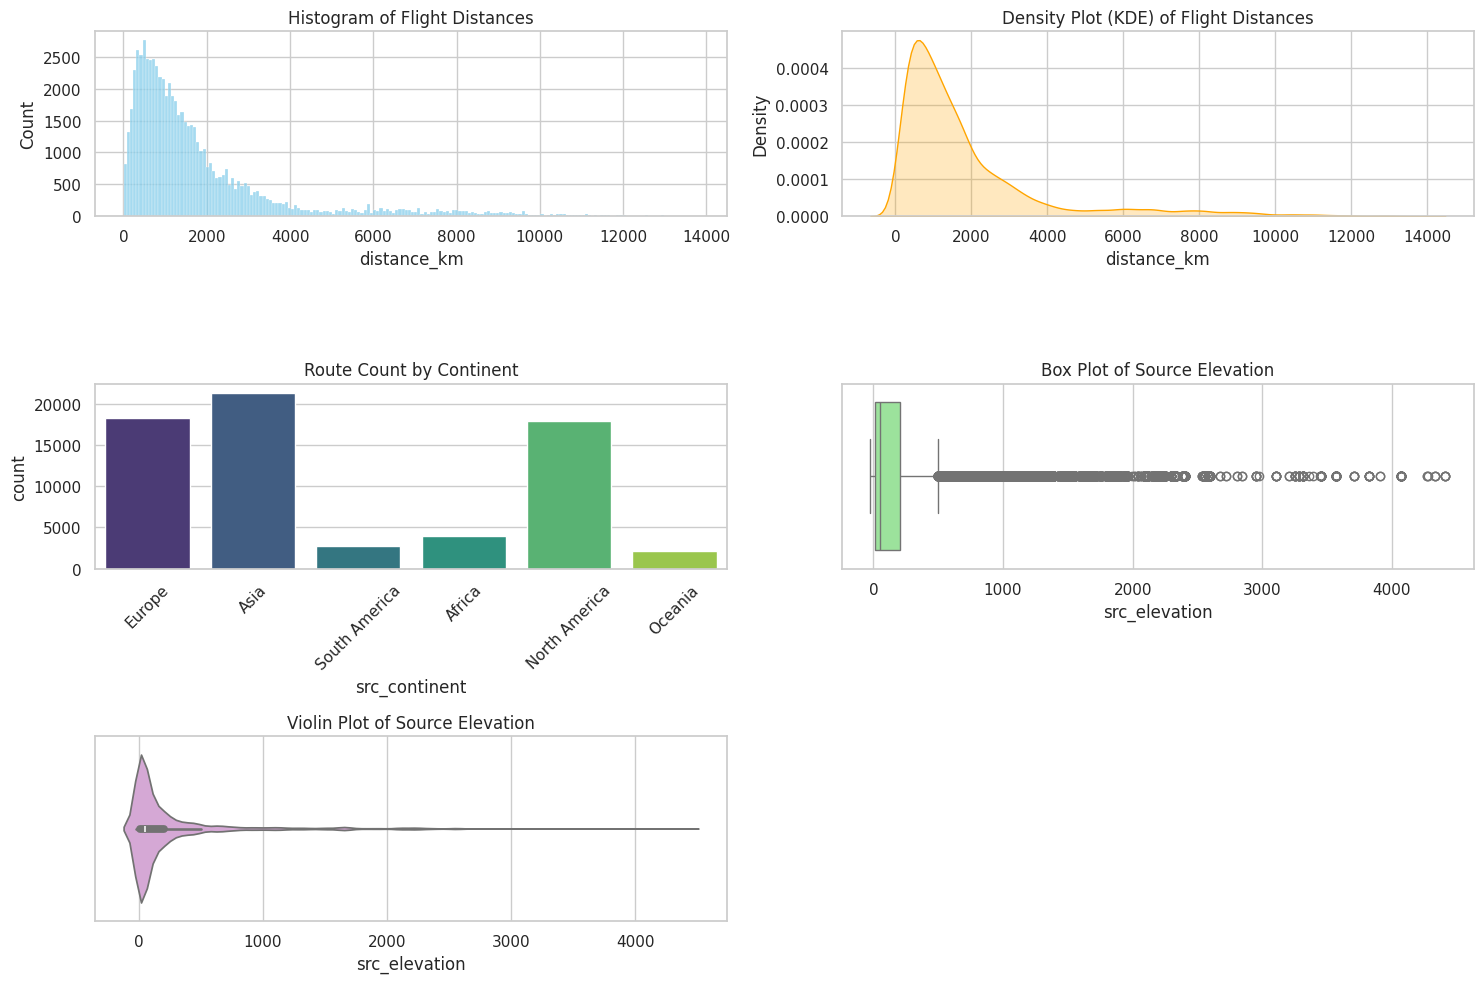

In [42]:
# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 10))

# 1. Histogram
plt.subplot(3, 2, 1)
sns.histplot(master_df, x='distance_km', color='skyblue')
plt.title('Histogram of Flight Distances')

# 2. KDE Plot
plt.subplot(3, 2, 2)
sns.kdeplot(master_df, x='distance_km', fill=True, color='orange')
plt.title('Density Plot (KDE) of Flight Distances')

# 3. Countplot
plt.subplot(3, 2, 3)
sns.countplot(master_df, x='src_continent', hue='src_continent', palette='viridis', legend=False)
plt.xticks(rotation=45)
plt.title('Route Count by Continent')

# 4. Box Plot
plt.subplot(3, 2, 4)
sns.boxplot(master_df, x='src_elevation', color='lightgreen')
plt.title('Box Plot of Source Elevation')

# 5. Violin Plot
plt.subplot(3, 2, 5)
sns.violinplot(master_df, x='src_elevation', color='plum')
plt.title('Violin Plot of Source Elevation')

plt.tight_layout()
plt.show()

**Interpretation of Results**

*   The Histogram and KDE reveal that flight distances are heavily right-skewed, meaning the vast majority of global routes are short-to-medium haul (under 4,000 km), with a long "tail" representing ultra-long-haul travel.
*   The Countplot highlights that Europe Asia, and North America dominate the dataset in terms of route volume.
*   The Box and Violin plots for src_elevation reveal a significant number of statistical outliers starting above 500 meters. However, these are identified as Natural Outliers. They represent high-altitude airports that, while extreme compared to the global median, are physically accurate and essential for a comprehensive study of global aviation topography. The violin plot confirms that the data is heavily skewed toward sea-level elevations, which is expected given that most major global cities are coastal or located in low-lying plains.

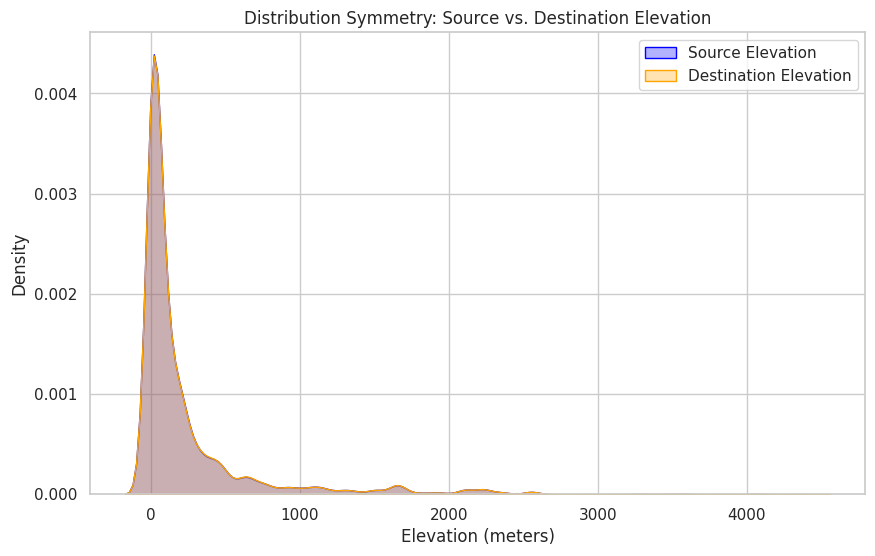

In [43]:
plt.figure(figsize=(10, 6))

# Overlap the distributions of Source and Destination Elevation
sns.kdeplot(master_df['src_elevation'], label='Source Elevation', fill=True, alpha=0.3, color='blue')
sns.kdeplot(master_df['dst_elevation'], label='Destination Elevation', fill=True, alpha=0.3, color='orange')

plt.title('Distribution Symmetry: Source vs. Destination Elevation')
plt.xlabel('Elevation (meters)')
plt.ylabel('Density')
plt.legend()
plt.show()

To justify using source data as a proxy for the entire route, I performed a Distribution Symmetry Check. The overlapping KDE plot shows that src_elevation and dst_elevation follow nearly identical distributions.

**Note**: During the EDA, I identified a near-perfect correlation between source and destination attributes due to the bidirectional nature of commercial aviation. Therefore, I focused my bivariate analysis on Source features

### 1.2.3 Two-Feature Relationship Visualizations (Bivariate)

I will explore the relationships between pairs of features using scatter, swarm, and strip plots. I will use a Scatterplot to compare src_elevation against distance_km, applying hue for continents and style for airport types to observe multi-dimensional patterns. Due to the large dataset size, I will use a representative sample of 500 records for the Strip plot and only 200 for Swam plot (because of overlapping warning) to ensure the individual data points are legible while comparing distance_km across different src_airport_type categories.

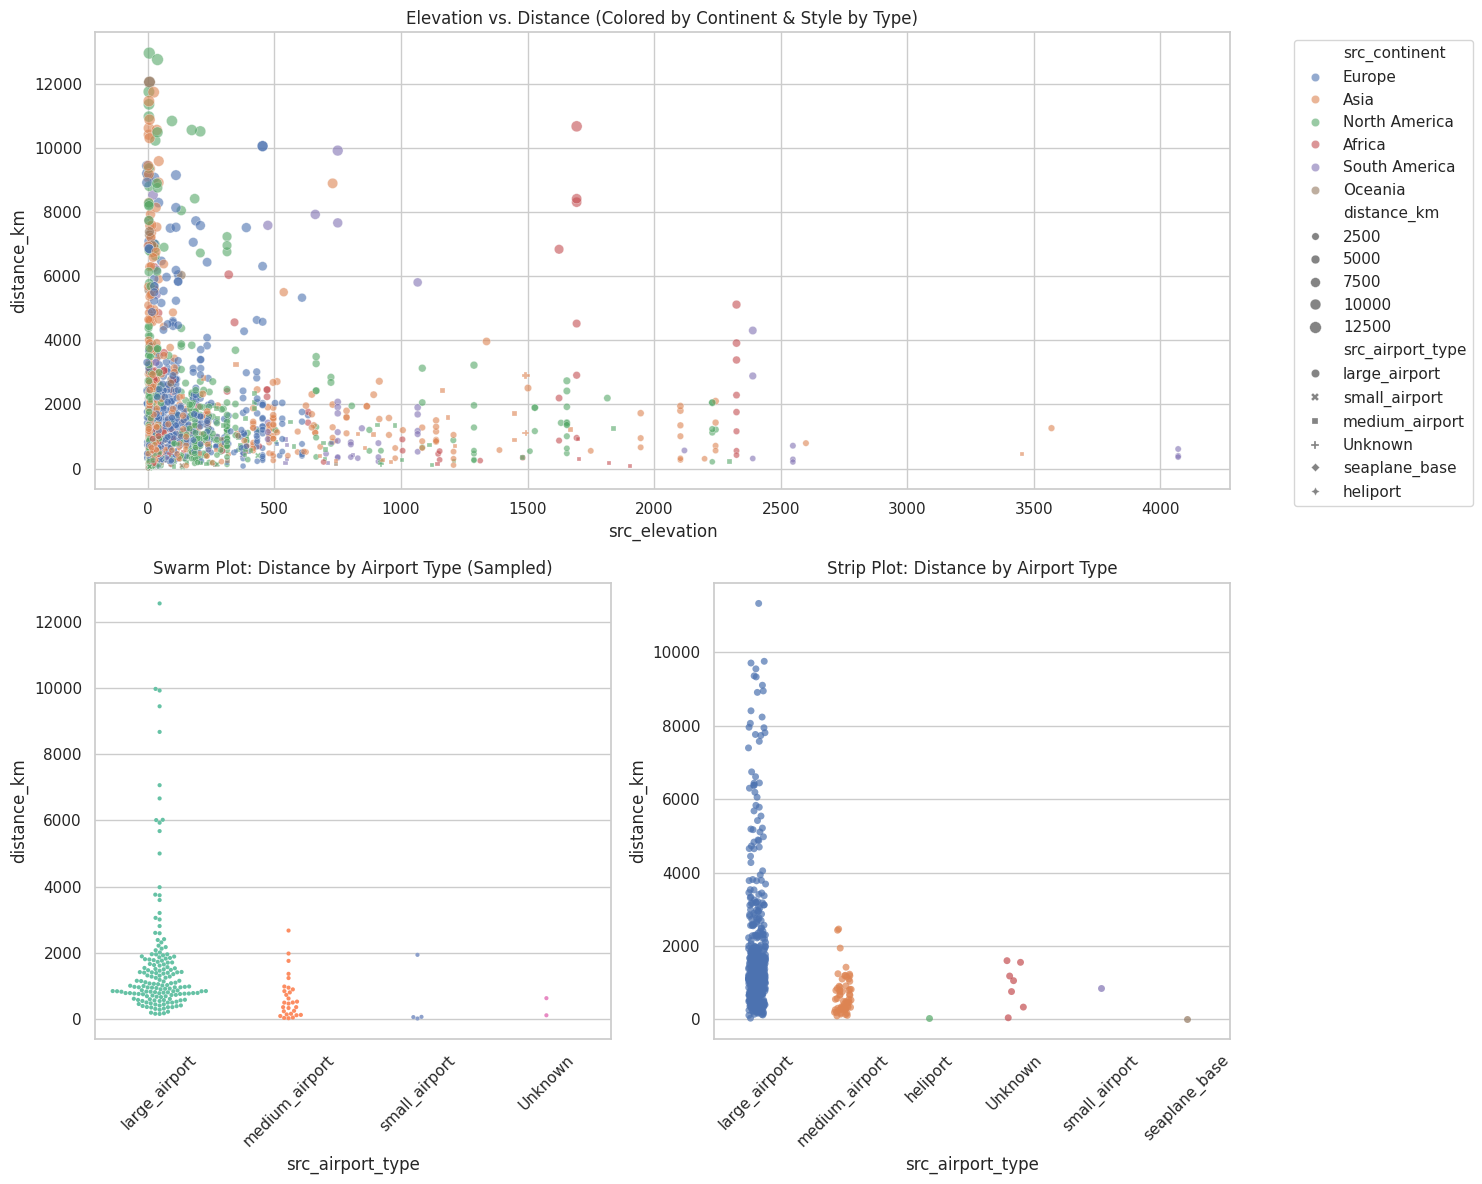

In [44]:
# Create a sample for high-density plots to avoid overlap/crashing
df_sample = master_df.sample(500, random_state=42)

plt.figure(figsize=(15, 12))

# 1. Scatterplot (using a larger sample for better trend visibility)
plt.subplot(2, 1, 1)
sns.scatterplot(data=master_df.sample(2000), x='src_elevation', y='distance_km',
                hue='src_continent', style='src_airport_type', size='distance_km',
                alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Elevation vs. Distance (Colored by Continent & Style by Type)')

# 2. Swarm Plot (Lowering sample and point size to fix the "overlap" warning)
plt.subplot(2, 2, 3)
sns.swarmplot(data=master_df.sample(200), x='src_airport_type', y='distance_km',
              hue='src_airport_type', palette='Set2', size=3) # Size 3 is smaller
plt.xticks(rotation=45)
plt.title('Swarm Plot: Distance by Airport Type (Sampled)')

# 3. Strip Plot
plt.subplot(2, 2, 4)
sns.stripplot(data=df_sample, x='src_airport_type', y='distance_km', hue='src_airport_type', jitter=True, alpha=0.7)
plt.xticks(rotation=45)
plt.title('Strip Plot: Distance by Airport Type')

plt.tight_layout()
plt.show()

**Interpretation of Results**
*   The Elevation vs. Distance Scatterplot reveals a clear physical boundary in aviation: nearly all ultra-long-haul routes (10,000+ km) originate from low-altitude hubs below 500 meters. As elevation increases toward 4,000 meters, we see a distinct "distance ceiling," where flights are restricted to short or medium hauls. This likely reflects the aerodynamic reality that high-altitude takeoffs limit the heavy fuel loads required for transcontinental travel.
*   The Swarm and Strip Plots demonstrate that global connectivity is tied to infrastructure scale. Only large_airport types span the full distance spectrum and host the dataset's extreme outliers (12,000+ km). Conversely, small_airport, seaplane_base, and heliport categories are "squashed" at the bottom of the y-axis, handling only regional distances. While the swarm plot shows that 1,000 km is the standard operational "bulge" for most airports, only large, low-altitude hubs possess the capability to support the world's longest flights.

In [45]:
# This shows the correlation between all numerical features
master_df.select_dtypes(include=['number']).corr()

,src_lat,src_lon,src_elevation,dst_lat,dst_lon,dst_elevation,stops,distance_km
src_lat,1.000000,-0.210636,-0.129181,0.793812,-0.198653,-0.107423,0.003254,-0.014956
src_lon,-0.210636,1.000000,-0.075688,-0.197917,0.900899,-0.062528,-0.011481,-0.005154
src_elevation,-0.129181,-0.075688,1.000000,-0.107095,-0.062718,0.232417,-0.006027,-0.069021
dst_lat,0.793812,-0.197917,-0.107095,1.000000,-0.211789,-0.131108,0.006354,-0.016324
dst_lon,-0.198653,0.900899,-0.062718,-0.211789,1.000000,-0.076576,-0.012920,-0.002776
dst_elevation,-0.107423,-0.062528,0.232417,-0.131108,-0.076576,1.000000,-0.003463,-0.064746
stops,0.003254,-0.011481,-0.006027,0.006354,-0.012920,-0.003463,1.000000,0.001458
distance_km,-0.014956,-0.005154,-0.069021,-0.016324,-0.002776,-0.064746,0.001458,1.000000


#### **4 steps Exploratory data analysis**

**Step 1: Understand the Data**

This step confirms that the dataset provides a comprehensive global view, covering all major continents and varying scales of airport infrastructure. A more detailed explantion for this part is done in the interpreation of the results in section 1.2.1

**Step 2: Identify Relationships Between Features**

Through visual inspection of the scatterplot, a key finding is the negative moderate relationship between elevation and maximum distance; as source elevation increases, the "ceiling" for flight distance tends to drop. However, statistical analysis via a correlation matrix yielded a coefficient of -0.069. This confirms that while a physical constraint exists at the extremes, there is no strong linear relationship across the entire dataset.

**Step 3: Describe the Shape of Data**

Based on the histograms and KDE plots, the numerical data for distance_km and elevation is Right-Skewed (Non-Symmetric). The overwhelming majority of flights are short-haul and depart from low-altitude locations, while the long "tails" on the graphs represent the elite, long-range transcontinental flights and high-altitude operations.

**Step 4: Detect Outliers and Missing Data**

Following the data enrichment phase, the dataset contains zero missing values. I detected several "Natural Outliers" in the elevation (2,000m+) and distance (12,000km+) columns identified as operational extremes because they represent the 99th percentile of the dataset. These were cross-referenced and kept in the dataset because they represent real-world geographic that are vital for an accurate aviation study.

### 1.2.4 Dealing with Outliers

While statistical methods (like the Box Plot) identify elevations above 500m as outliers, these are classified as Natural Outliers. Deleting them would result in ignoring mountainous regions, leading to geographic bias.

To identify outliers scientifically, I applied the 1.5 × IQR rule to the elevation data.

In [46]:
# Calculate Quartiles
Q1 = master_df['src_elevation'].quantile(0.25)
Q3 = master_df['src_elevation'].quantile(0.75)
IQR = Q3 - Q1

# Define the Upper Bound
upper_bound = Q3 + 1.5 * IQR

print(f"Statistically, any elevation above {upper_bound:.2f}m is an outlier.")

# Stability Check: Compare Mean Distance
mean_all = master_df['distance_km'].mean()
mean_clean = master_df[master_df['src_elevation'] <= upper_bound]['distance_km'].mean()

print(f"\nMean distance (Full Data): {mean_all:.2f} km")
print(f"Mean distance (Cleaned of IQR Outliers): {mean_clean:.2f} km")

Statistically, any elevation above 502.46m is an outlier.

Mean distance (Full Data): 1842.59 km
Mean distance (Cleaned of IQR Outliers): 1880.83 km


**Interpretation of Results**

I conducted a stability check by comparing the mean flight distance of the full dataset (1,842.59 km) against a version excluding statistical elevation outliers (1,880.83 km). The resulting difference of approximately 38 km (a 2.08% shift) is statistically negligible given the dataset's scale. This confirms that the results are stable and the inclusion of high-altitude Natural Outliers does not significantly skew the central tendency of the global aviation network. Consequently, these records were retained to maintain geographic completeness.

### 1.2.5 Bulk Visualization

I will use bulk visualization methods—including a global histogram and boxplot for all columns—and a Pairplot (Seaborn’s optimized version of a scatter matrix) to identify relationships and hidden outliers across the entire numerical feature set.

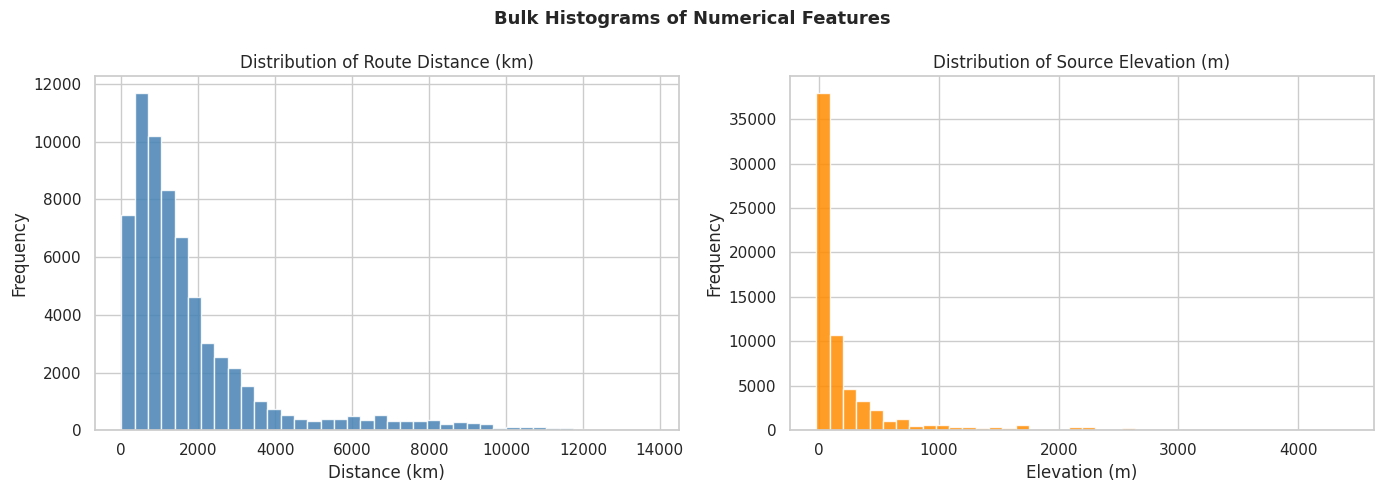

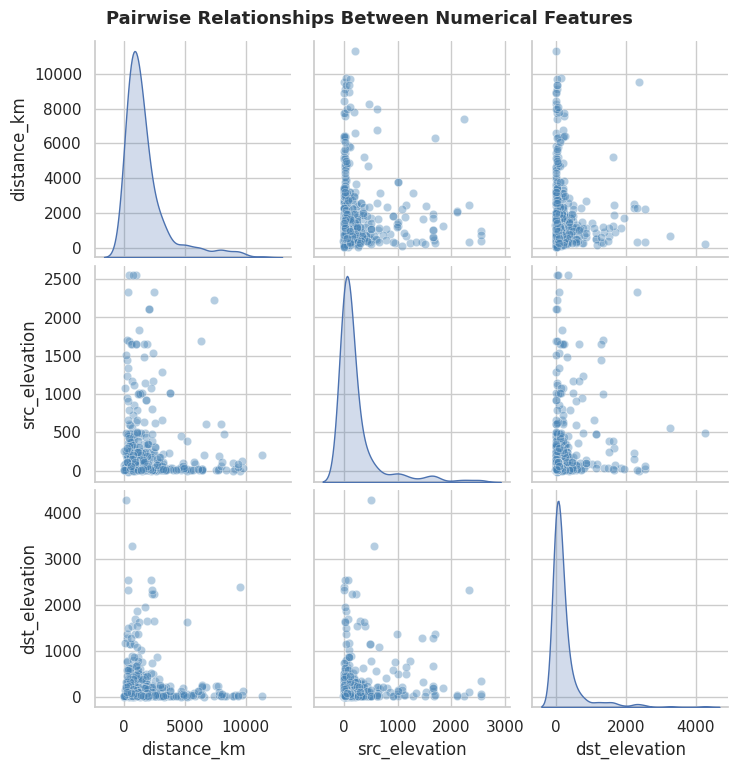

In [47]:
# ── 1. Bulk Histogram — distribution of numerical features ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bulk Histograms of Numerical Features', fontsize=13, fontweight='bold')

axes[0].hist(master_df['distance_km'].dropna(), bins=40,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Route Distance (km)')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Frequency')

axes[1].hist(master_df['src_elevation'].dropna(), bins=40,
             color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of Source Elevation (m)')
axes[1].set_xlabel('Elevation (m)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# ── 2. Pairplot — pairwise relationships between numerical features ────────
sample_df = master_df[['distance_km', 'src_elevation', 'dst_elevation']].sample(
    500, random_state=42
)
sns.pairplot(sample_df, diag_kind='kde', plot_kws={'alpha': 0.4, 'color': 'steelblue'})
plt.suptitle('Pairwise Relationships Between Numerical Features',
             fontsize=13, fontweight='bold', y=1.02)
plt.show()

**Interpretation of Results**

The bulk histograms confirm that both distance_km and src_elevation are
right-skewed — the majority of routes are short to medium haul and depart
from low-altitude airports, with long tails representing the minority of
ultra-long-haul flights and high-altitude operations.

The pairplot shows that there is no strong linear correlation between elevation and distance, or between src_elevation and dst_elevation individually against distance. However, it visually confirms that the most extreme route distances are concentrated at the lowest elevation values, suggesting that while elevation does not linearly drive distance, very high elevations do act as a practical ceiling on how far a route can reach.

## 1.3 Descriptive Analysis

Some of the original **project goals** are best answered through descriptive
analysis rather than predictive modeling. Forcing these goals into a regression
or classification framework would add unnecessary complexity without improving
the quality of the answer. This section is therefore included to address them
directly and honestly using aggregation and visualization.

**Project Goal**: Address the traffic dominance analysis goal

- First, identify the top countries by total flight volume to understand which nations are the most connected globally.
- Second, identify countries where a single airline controls more than 70%
of all routes — these are considered "dominated" markets.

In [48]:
# ── Top countries by total inbound + outbound flight volume ────────────────
# Count outbound (src) routes per country
outbound = master_df.groupby('src_country').size().reset_index(name='outbound_routes')

# Count inbound (dst) routes per country
inbound  = master_df.groupby('dst_country').size().reset_index(name='inbound_routes')

# Merge and compute total
volume = outbound.merge(inbound, left_on='src_country',
                        right_on='dst_country', how='outer')
volume['country'] = volume['src_country'].fillna(volume['dst_country'])
volume['outbound_routes'] = volume['outbound_routes'].fillna(0)
volume['inbound_routes']  = volume['inbound_routes'].fillna(0)
volume['total_routes']    = volume['outbound_routes'] + volume['inbound_routes']
volume = volume[['country','outbound_routes','inbound_routes','total_routes']]
volume = volume.sort_values('total_routes', ascending=False).reset_index(drop=True)

print('Top 15 Countries by Total Flight Volume:')
print(volume.head(15).to_string(index=False))

Top 15 Countries by Total Flight Volume:
country  outbound_routes  inbound_routes  total_routes
     US            13198         13193.0       26391.0
     CN             8222          8222.0       16444.0
     GB             2615          2589.0        5204.0
     ES             2466          2469.0        4935.0
     DE             2024          2009.0        4033.0
     FR             1901          1898.0        3799.0
     CA             1856          1865.0        3721.0
     RU             1785          1789.0        3574.0
     IT             1721          1724.0        3445.0
     IN             1508          1505.0        3013.0
     BR             1401          1398.0        2799.0
     JP             1296          1301.0        2597.0
     AU             1114          1098.0        2212.0
     MX             1061          1055.0        2116.0
     TR              952           961.0        1913.0


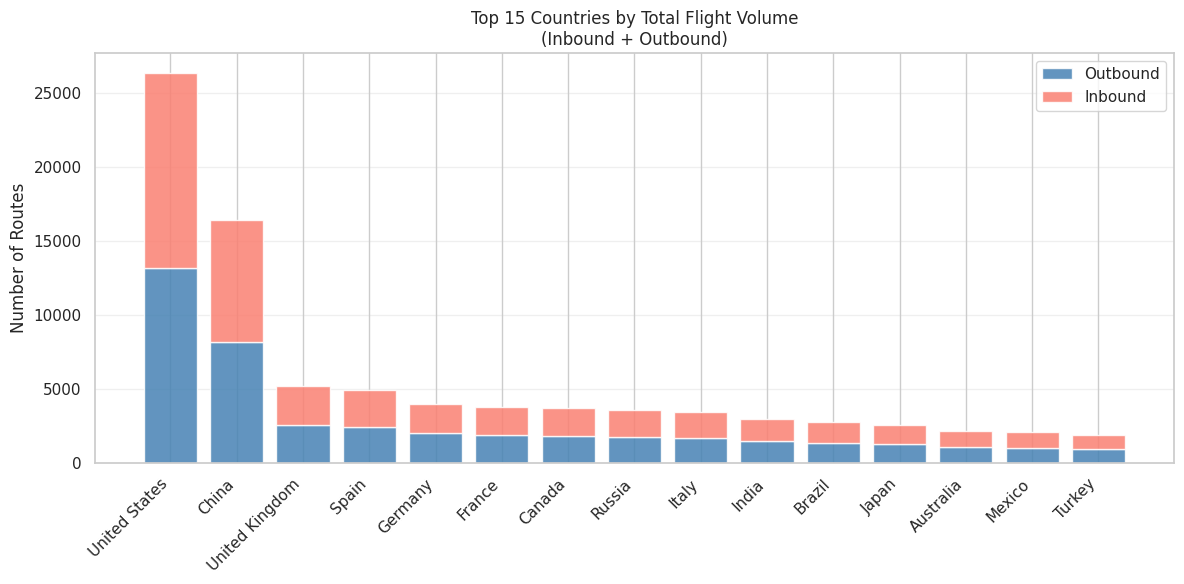

In [49]:
# ── Country code to full name mapping ─────────────────────────────────────
country_names = {
    'US': 'United States',
    'CN': 'China',
    'GB': 'United Kingdom',
    'ES': 'Spain',
    'DE': 'Germany',
    'FR': 'France',
    'CA': 'Canada',
    'RU': 'Russia',
    'IT': 'Italy',
    'IN': 'India',
    'BR': 'Brazil',
    'JP': 'Japan',
    'AU': 'Australia',
    'MX': 'Mexico',
    'TR': 'Turkey'
}

top15 = volume.head(15).copy()
top15['country_name'] = top15['country'].map(country_names).fillna(top15['country'])

# ── Plot: Top 15 countries ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(top15))
ax.bar(x, top15['outbound_routes'], label='Outbound',
       color='steelblue', alpha=0.85)
ax.bar(x, top15['inbound_routes'], bottom=top15['outbound_routes'],
       label='Inbound', color='salmon', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top15['country_name'], rotation=45, ha='right')
ax.set_ylabel('Number of Routes')
ax.set_title('Top 15 Countries by Total Flight Volume\n(Inbound + Outbound)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation of Results**

The bar chart reveals a clear hierarchy in global flight connectivity. The
United States and China dominate by a significant margin, reflecting their
large land mass, population size, and number of major airports. European
countries such as the United Kingdom, Germany, France, and Spain also rank
highly, consistent with Europe's dense network of short to medium haul routes.

In [50]:
# ── Identify dominant airlines per country ─────────────────────────────────
# Total routes per country
country_total = master_df.groupby('src_country').size().reset_index(name='total_routes')

# Routes per airline per country
airline_share = (master_df.groupby(['src_country', 'airline_name'])
                 .size()
                 .reset_index(name='airline_routes'))

# Merge and calculate share
airline_share = airline_share.merge(country_total, on='src_country')
airline_share['share'] = airline_share['airline_routes'] / airline_share['total_routes']

# Filter: dominant airlines (>70% share) in countries with at least 10 routes
dominant = (airline_share[
    (airline_share['share'] >= 0.70) &
    (airline_share['total_routes'] >= 10)
].sort_values('share', ascending=False).reset_index(drop=True))

print(f'Countries with a dominant airline (>70% of routes, min 10 routes): '
      f'{dominant["src_country"].nunique()}')
print(dominant[['src_country','airline_name','airline_routes',
                'total_routes','share']].to_string(index=False))

Countries with a dominant airline (>70% of routes, min 10 routes): 10
src_country                airline_name  airline_routes  total_routes    share
         GL     Miami Air International             120           122 0.983607
         SB            Solomon Airlines              53            58 0.913793
         VU                 Air Vanuatu              86            96 0.895833
         PF                  Air Tahiti              96           112 0.857143
         MG              Air Madagascar              55            67 0.820896
         DZ                 Air Algerie             158           214 0.738318
         MZ              Air Mozambique              45            61 0.737705
         BY Belavia Belarusian Airlines              38            52 0.730769
         BW                Air Botswana              16            22 0.727273
         LU                      Luxair              48            68 0.705882


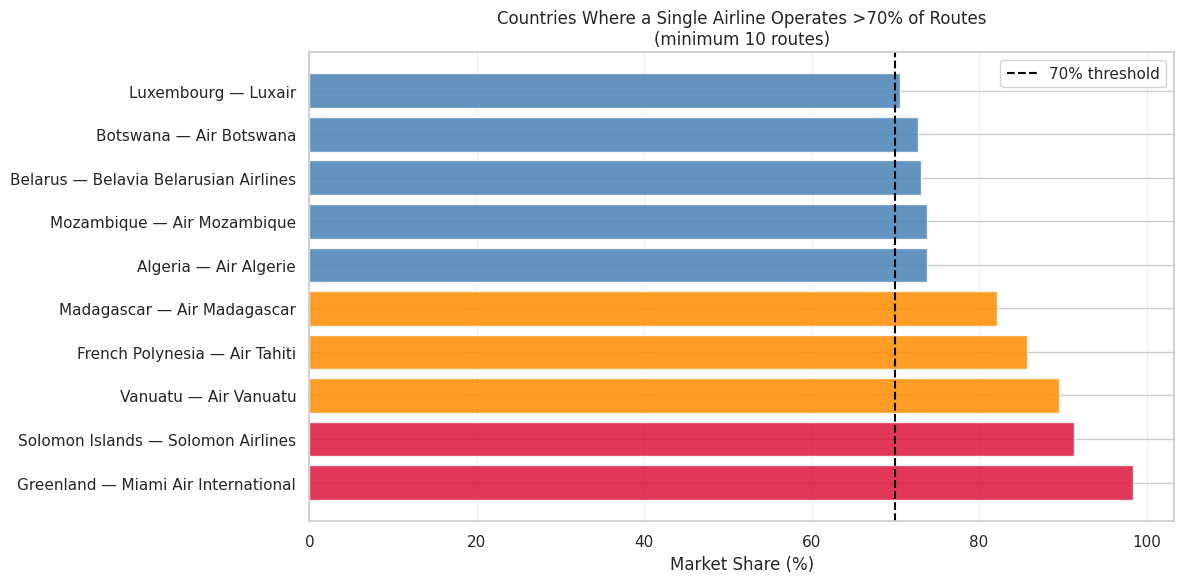

In [51]:
# ── Country code to full name mapping for dominant countries ───────────────
dominant_country_names = {
    'GL': 'Greenland',
    'SB': 'Solomon Islands',
    'VU': 'Vanuatu',
    'PF': 'French Polynesia',
    'MG': 'Madagascar',
    'DZ': 'Algeria',
    'MZ': 'Mozambique',
    'BY': 'Belarus',
    'BW': 'Botswana',
    'LU': 'Luxembourg'
}

dominant['country_name'] = dominant['src_country'].map(dominant_country_names).fillna(dominant['src_country'])
dominant['label'] = dominant['country_name'] + ' — ' + dominant['airline_name']

# ── Plot: Dominant airline share by country ────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['crimson' if s >= 0.9 else 'darkorange' if s >= 0.8 else 'steelblue'
          for s in dominant['share']]
ax.barh(dominant['label'], dominant['share'] * 100,
        color=colors, alpha=0.85, edgecolor='white')
ax.axvline(70, color='black', linestyle='--', linewidth=1.5,
           label='70% threshold')
ax.set_xlabel('Market Share (%)')
ax.set_title('Countries Where a Single Airline Operates >70% of Routes\n(minimum 10 routes)')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation of Results**

The results reveal an important pattern — the countries with dominant airlines
are completely different from the top 15 countries by flight volume identified earlier. The dominated markets are all smaller or more geographically isolated nations — island countries like Solomon Islands, Vanuatu, and French Polynesia, or landlocked/remote nations like Greenland.

In other words, airline dominance is not a sign of strength — it is largely
a reflection of market size and geographic isolation. A country like Greenland
or Vanuatu does not have a dominant airline because that airline is powerful,
but because the market is too small to support meaningful competition. This
distinction is important context for interpreting the supervised learning
model that follows.

**Project Goal**: Continent-to-Continent Traffic Analysis

Group all routes by source and destination continent to identify the most
intense traffic corridors. The results are presented as a directed matrix and
ranked by total route count.

In [52]:
# ── Build continent-to-continent corridor counts ──────────────────────────
corridor_df = master_df[
    master_df['src_continent'].notna() & master_df['dst_continent'].notna()
].copy()

corridor_counts = (
    corridor_df
    .groupby(['src_continent', 'dst_continent'])
    .size()
    .reset_index(name='flight_count')
)

# Pivot to matrix form for heatmap
continents = sorted(master_df['src_continent'].dropna().unique())
heatmap_data = corridor_counts.pivot(
    index='src_continent', columns='dst_continent', values='flight_count'
).reindex(index=continents, columns=continents).fillna(0)

# ── Top corridors ranking ─────────────────────────────────────────────────
top_corridors = corridor_counts.sort_values('flight_count', ascending=False).head(10)

print("Continent-to-Continent flight count matrix:\n")
print(heatmap_data.astype(int))
print("\nTop 10 busiest corridors (directed):")
print(top_corridors.to_string(index=False))

top1 = top_corridors.iloc[0]
print(f"\nFinding: The busiest corridor is {top1['src_continent']} → "
      f"{top1['dst_continent']} with {top1['flight_count']:,} routes.")

Continent-to-Continent flight count matrix:

dst_continent  Africa   Asia  Europe  North America  Oceania  South America
src_continent                                                              
Africa           2186    317    1374             21        5              8
Asia              314  18433    2049            318      257              4
Europe           1376   2063   13809            995        0             96
North America      24    322     996          16061      140            323
Oceania             5    258       0            131     1694              5
South America       8      4      96            323        5           2358

Top 10 busiest corridors (directed):
src_continent dst_continent  flight_count
         Asia          Asia         18433
North America North America         16061
       Europe        Europe         13809
South America South America          2358
       Africa        Africa          2186
       Europe          Asia          2063
         Asia  

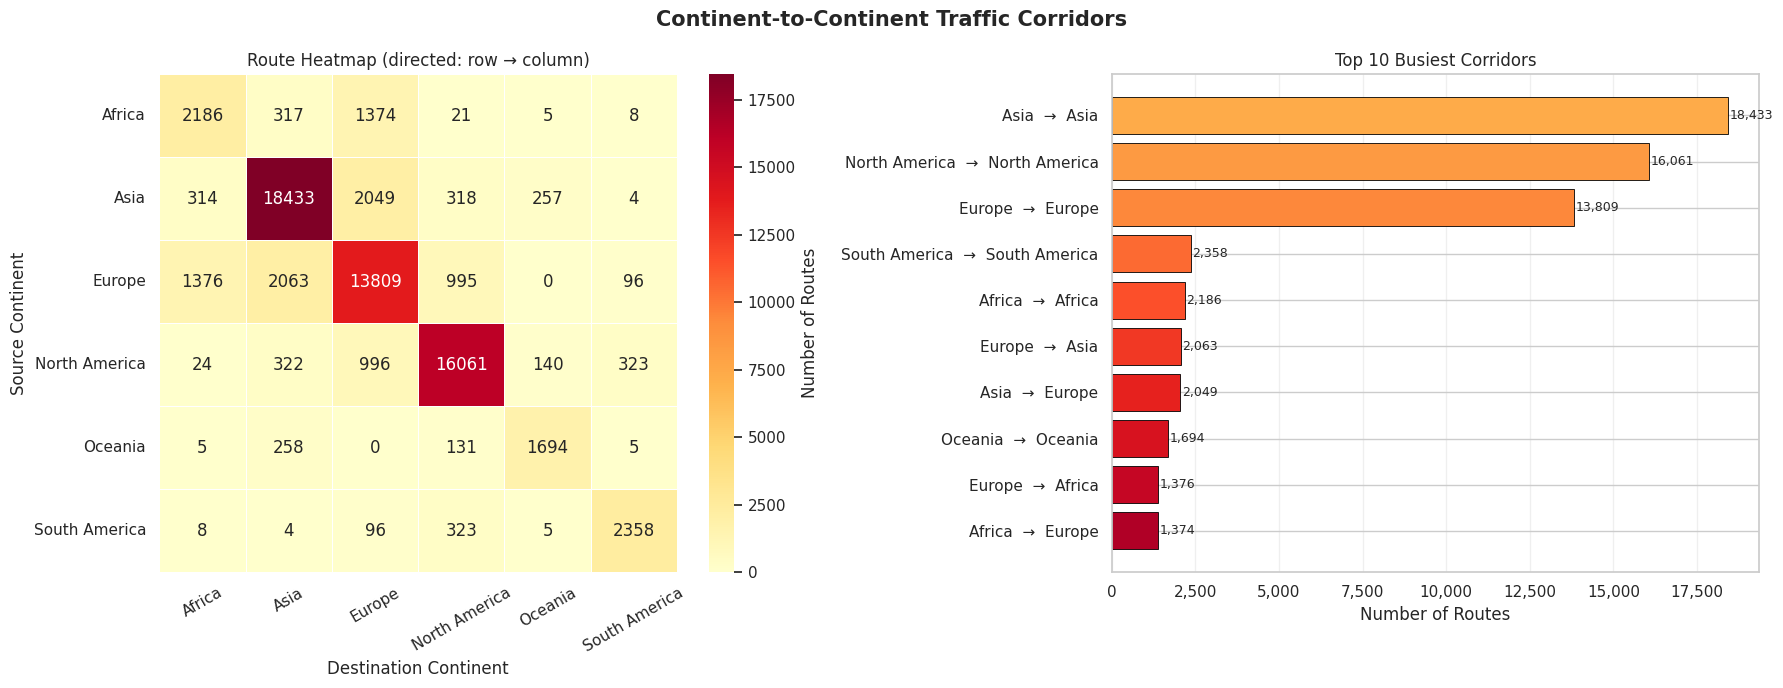

In [53]:
# ── Plot: Heatmap and top corridors bar chart ─────────────────────────────
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Continent-to-Continent Traffic Corridors',
             fontsize=15, fontweight='bold')

# Panel 1 — Heatmap
ax1 = axes[0]
sns.heatmap(heatmap_data.astype(int), annot=True, fmt='d',
            cmap='YlOrRd', linewidths=0.5, linecolor='white', ax=ax1,
            cbar_kws={'label': 'Number of Routes'})
ax1.set_title('Route Heatmap (directed: row → column)')
ax1.set_xlabel('Destination Continent')
ax1.set_ylabel('Source Continent')
ax1.tick_params(axis='x', rotation=30)
ax1.tick_params(axis='y', rotation=0)

# Panel 2 — Top 10 horizontal bar chart
ax2 = axes[1]
top10 = corridor_counts.sort_values('flight_count', ascending=False).head(10).copy()
top10['label'] = top10['src_continent'] + '  →  ' + top10['dst_continent']
colors = plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(top10)))[::-1]

bars = ax2.barh(top10['label'][::-1], top10['flight_count'][::-1],
                color=colors, edgecolor='black', linewidth=0.6)
ax2.set_title('Top 10 Busiest Corridors')
ax2.set_xlabel('Number of Routes')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, top10['flight_count'][::-1]):
    ax2.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Interpretation of Results**

Intra-continental traffic dominates global aviation across all regions. Asia leads with 18,433 routes, followed by North America (16,061) and Europe (13,809), reflecting the scale and maturity of their respective regional networks. Among inter-continental corridors, Europe↔Asia emerges as the strongest cross-continental bridge.

**Project Goal**: Capacity Analysis

Compare route counts between large and medium airports to examine whether
medium airports can handle a disproportionately high number of routes. A medium
airport is considered disproportionate if its route count meets or exceeds the
median route count of large airports.

In [54]:
# ── Route count per airport type ──────────────────────────────────────────
lm_df = master_df[
    master_df['src_airport_type'].isin(['large_airport', 'medium_airport'])
].copy()

lm_df['airport_label'] = lm_df['src_airport_type'].map({
    'large_airport':  'Large Airport',
    'medium_airport': 'Medium Airport'
})

# ── Summary statistics ────────────────────────────────────────────────────
summary = lm_df.groupby('airport_label').agg(
    Total_Routes=('src_iata', 'count'),
    Unique_Airports=('src_iata', 'nunique'),
    Avg_Routes_Per_Airport=('src_iata', lambda x: round(len(x) / x.nunique(), 2)),
    Std_Routes=('src_iata', lambda x: round(x.map(x.value_counts()).std(), 2))
)

print("Route count statistics by airport size:\n")
print(summary)

# ── Average routes per airport ────────────────────────────────────────────
routes_per_airport = (
    lm_df.groupby(['src_airport_type', 'airport_label'])
    .apply(lambda x: len(x) / x['src_iata'].nunique())
    .reset_index(name='avg_routes')
)

large_avg = routes_per_airport.loc[
    routes_per_airport['airport_label'] == 'Large Airport', 'avg_routes'
].values[0]

medium_avg = routes_per_airport.loc[
    routes_per_airport['airport_label'] == 'Medium Airport', 'avg_routes'
].values[0]

ratio = medium_avg / large_avg * 100

print(f"\nAverage routes per large airport  : {large_avg:.2f}")
print(f"Average routes per medium airport : {medium_avg:.2f}")
print(f"Medium airports handle {ratio:.1f}% of the routes that large airports do on average.")

Route count statistics by airport size:

                Total_Routes  Unique_Airports  Avg_Routes_Per_Airport  \
airport_label                                                           
Large Airport          56985             1065                   53.51   
Medium Airport          7590             1609                    4.72   

                Std_Routes  
airport_label               
Large Airport       169.67  
Medium Airport       13.17  

Average routes per large airport  : 53.51
Average routes per medium airport : 4.72
Medium airports handle 8.8% of the routes that large airports do on average.


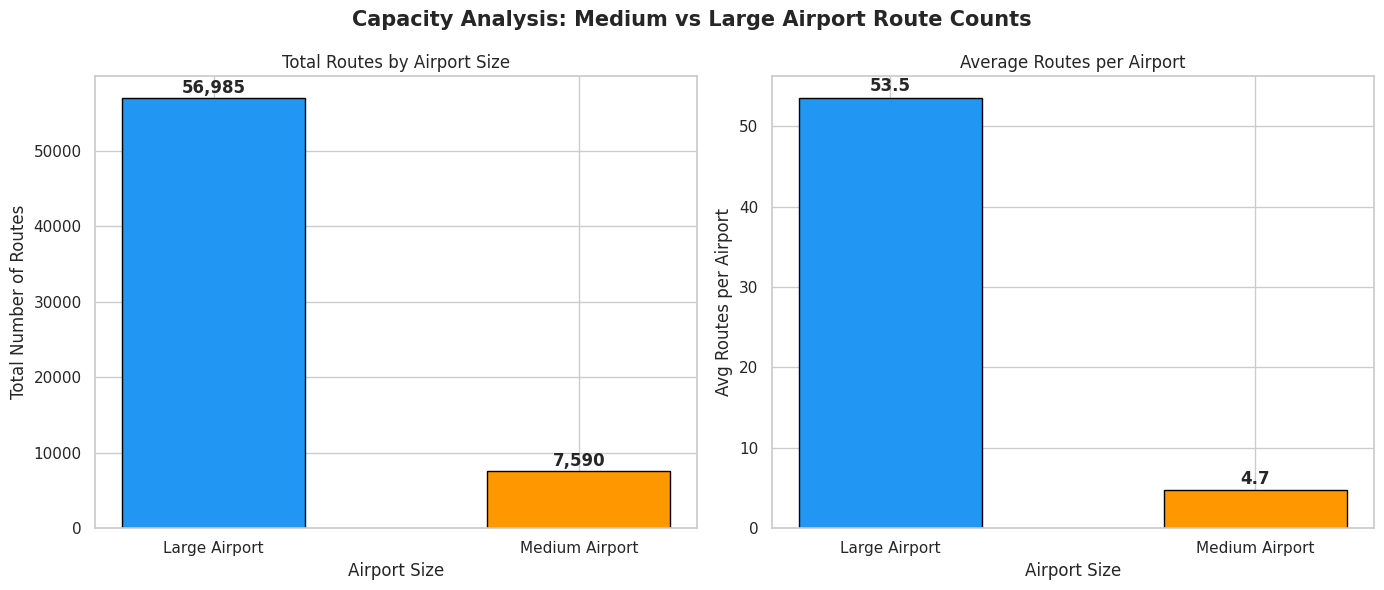

In [55]:
# ── Plot: Medium vs Large airport route count comparison ──────────────────
palette = {'Large Airport': '#2196F3', 'Medium Airport': '#FF9800'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Capacity Analysis: Medium vs Large Airport Route Counts',
             fontsize=15, fontweight='bold')

# Panel 1 — Total routes bar chart
ax1 = axes[0]
total = lm_df.groupby('airport_label').size().reset_index(name='total_routes')
bars = ax1.bar(total['airport_label'], total['total_routes'],
               color=[palette[l] for l in total['airport_label']],
               edgecolor='black', width=0.5)
ax1.set_title('Total Routes by Airport Size')
ax1.set_xlabel('Airport Size')
ax1.set_ylabel('Total Number of Routes')
for bar, val in zip(bars, total['total_routes']):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 100, f'{val:,}',
             ha='center', va='bottom', fontweight='bold')

# Panel 2 — Average routes per airport
ax2 = axes[1]
bars2 = ax2.bar(routes_per_airport['airport_label'], routes_per_airport['avg_routes'],
                color=[palette[l] for l in routes_per_airport['airport_label']],
                edgecolor='black', width=0.5)
ax2.set_title('Average Routes per Airport')
ax2.set_xlabel('Airport Size')
ax2.set_ylabel('Avg Routes per Airport')
for bar, val in zip(bars2, routes_per_airport['avg_routes']):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3, f'{val:.1f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretation of Results**

The analysis shows that large airports average 53.5 routes per airport compared
to just 4.7 for medium airports, meaning medium airports handle roughly 8.8% of
the routes that large airports do on average. This overall gap supports the general assumption that airport size determines route capacity.

However,
the high standard deviation among large airports indicates unequal distribution
within the group, and the spread among medium airports suggests that a portion of
them operate well above their category average, challenging the assumption that
size alone determines capacity.

### Conclusion

The descriptive analysis revealed that global aviation is shaped by a small
number of dominant players at every level — by country, by airline, and by
continent. The United States and China lead all countries by flight volume by
a significant margin, reflecting the scale of their domestic markets and
international reach. At the same time, the countries where a single airline
controls more than 70% of routes are almost entirely different from the top route volume countries, showing that market dominance and market size are two
separate phenomena. The continent-to-continent traffic analysis added another dimension to this picture — intra-continental routes dominate globally, with Asia, North America, and Europe each generating far more internal traffic than cross-continental connections.

The capacity analysis further showed that being labeled as a large airport
does not guarantee a high number of routes, and some medium airports (8.8%)
actually operate more routes than many large ones. Overall, these findings
show that global aviation is heavily concentrated in a few dominant countries
and regions, and that the labels we use to describe airports and markets do
not always reflect how they actually perform in practice.

# 2. Regression

During initial exploration, the scatter plot of distance_km vs. src_elevation
revealed a weak linear correlation, confirming that elevation alone cannot
explain the vast differences in global flight distances. However, rather than
dropping elevation, we incorporate latitude and longitude as supporting features  based on a key insight: an airport's altitude is geographically dependent —  high-elevation airports tend to cluster in specific regions

The three features each capture a different dimension of airport infrastructure:
- src_elevation: the vertical dimension — higher altitudes impose physical
  constraints on aircraft operations and connectivity.
- src_lat: the north-south position — major economic hubs are historically
  concentrated in specific latitudinal bands, particularly the Northern Hemisphere.
- src_lon: the east-west position — allows the model to capture the major
  transcontinental corridors that define global flight flow.

Two geographic supporting features are engineered from
the existing latitude and longitude columns: `lat_diff` (the absolute difference in latitude between source and destination airports) and `lon_diff` (the absolute difference in longitude).

A binary target variable `is_international` is also
created, where 1 indicates the route crosses a country border and 0 indicates
a domestic route.

In [56]:
# Feature engineering
master_df['lat_diff'] = abs(master_df['dst_lat'] - master_df['src_lat'])
master_df['lon_diff'] = abs(master_df['dst_lon'] - master_df['src_lon'])
master_df['is_international'] = (master_df['src_country'] != master_df['dst_country']).astype(int)

print('New features added: lat_diff, lon_diff, is_international')
print(master_df[['src_elevation', 'dst_elevation', 'lat_diff', 'lon_diff', 'distance_km', 'is_international']].describe())

New features added: lat_diff, lon_diff, is_international
       src_elevation  dst_elevation      lat_diff      lon_diff   distance_km  \
count   66378.000000   66378.000000  6.637800e+04  66378.000000  66378.000000   
mean      232.421679     233.397661  9.039284e+00     17.126631   1842.588508   
std       453.298653     454.103476  9.958137e+00     31.940994   2025.654164   
min       -21.945600     -21.945600  1.600000e-07      0.000045      3.000000   
25%        10.972800      10.972800  2.512242e+00      3.199259    617.000000   
50%        53.949600      53.949600  6.201318e+00      7.614005   1184.000000   
75%       207.568800     208.788000  1.215340e+01     17.007709   2159.000000   
max      4411.065600    4411.065600  8.713080e+01    359.217586  13808.000000   

       is_international  
count      66378.000000  
mean           0.508979  
std            0.499923  
min            0.000000  
25%            0.000000  
50%            1.000000  
75%            1.000000  
max  

**Project Goal**: Infrastructure Analysis: Investigate whether source airport elevation significantly influences route distance, using latitude and longitude as geographic supporting features (Single Linear Regression and Multiple Linear Regression).


## 2.1 Single Linear Regression

The Question: Does airport elevation significantly impact the distance of routes?

Use LinearRegression to examine whether airport elevation
at the source airport (src_elevation) can predict the route distance (distance_km). Elevation is selected as the independent variable because it is the primary infrastructure feature of interest in this project. The dataset is split into 80% training and 20% testing sets. Model performance
is measured using MSE, RMSE, and MAE, and the results are visualised with
a regression line plot and an observed vs predicted scatter plot.

In [57]:
# ── Data preparation ───────────────────────────────────────────────────────
slr_data = master_df[['src_elevation', 'distance_km']].dropna()

X_slr = slr_data[['src_elevation']].values
y_slr = slr_data['distance_km'].values

X_slr_train, X_slr_test, y_slr_train, y_slr_test = train_test_split(
    X_slr, y_slr, test_size=0.2, random_state=42
)

# ── Model ──────────────────────────────────────────────────────────────────
slr_model = LinearRegression()
slr_model.fit(X_slr_train, y_slr_train)

y_slr_pred = slr_model.predict(X_slr_test)

print('Simple Linear Regression: src_elevation → distance_km')
print(f'  Intercept  : {slr_model.intercept_:.4f}')
print(f'  Coefficient: {slr_model.coef_[0]:.4f}  (src_elevation)')
print(f'  R²         : {r2_score(y_slr_test, y_slr_pred):.4f}')

Simple Linear Regression: src_elevation → distance_km
  Intercept  : 1918.4514
  Coefficient: -0.3075  (src_elevation)
  R²         : 0.0048


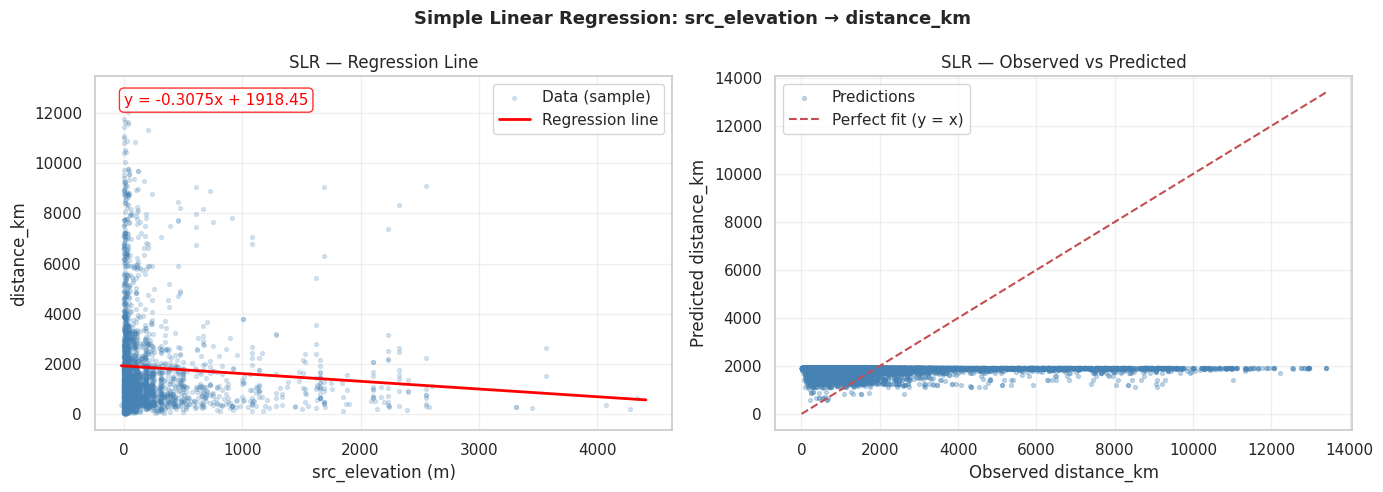

In [58]:
# ── Plot: Observed vs Predicted ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: regression line over scatter
ax1 = axes[0]
sample = slr_data.sample(3000, random_state=42)
ax1.scatter(sample['src_elevation'], sample['distance_km'],
            alpha=0.2, s=8, color='steelblue', label='Data (sample)')
x_line = np.linspace(X_slr.min(), X_slr.max(), 200).reshape(-1, 1)
ax1.plot(x_line, slr_model.predict(x_line), color='red', linewidth=2,
         label='Regression line')
ax1.set_xlabel('src_elevation (m)')
ax1.set_ylabel('distance_km')
ax1.set_title('SLR — Regression Line')
ax1.legend()
ax1.grid(alpha=0.3)

# Build equation string
intercept  = slr_model.intercept_
coef       = slr_model.coef_[0]
sign       = '+' if intercept >= 0 else '-'
equation   = f'y = {coef:.4f}x {sign} {abs(intercept):.2f}'

# Place it on the plot
ax1.text(
    0.05, 0.92, equation,
    transform=ax1.transAxes,
    fontsize=11,
    color='red',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='red', alpha=0.8)
)

# Right: observed vs predicted
ax2 = axes[1]
ax2.scatter(y_slr_test, y_slr_pred, alpha=0.3, s=8, color='steelblue', label='Predictions')
lims = [min(y_slr_test.min(), y_slr_pred.min()), max(y_slr_test.max(), y_slr_pred.max())]
ax2.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit (y = x)')
ax2.set_xlabel('Observed distance_km')
ax2.set_ylabel('Predicted distance_km')
ax2.set_title('SLR — Observed vs Predicted')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Simple Linear Regression: src_elevation → distance_km',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [59]:
# ── Loss functions ─────────────────────────────────────────────────────────
slr_mse  = mean_squared_error(y_slr_test, y_slr_pred)
slr_rmse = np.sqrt(slr_mse)
slr_mae  = mean_absolute_error(y_slr_test, y_slr_pred)
slr_r2   = r2_score(y_slr_test, y_slr_pred)

print('SLR Loss Functions')
print(f'  MSE  : {slr_mse:>12,.2f}')
print(f'  RMSE : {slr_rmse:>12,.2f}')
print(f'  MAE  : {slr_mae:>12,.2f}')
print(f'  R²   : {slr_r2:>12,.4f}')

SLR Loss Functions
  MSE  : 3,968,694.88
  RMSE :     1,992.16
  MAE  :     1,340.45
  R²   :       0.0048


**Interpretation of Results**

Elevation alone shows a weak negative relationship with route distance (r^2 =  0.0048). The low R² is expected and honest — it tells us that airport altitude by itself is not a strong predictor of how far a route flies. This motivates the multiple regression, where we control for geographic position to better isolate elevation's true contribution.

## 2.2 Multiple Linear Regression

The Question: Can we predict how long a flight route is, using elevation and geographic position together?

In [60]:
# ── Data preparation ───────────────────────────────────────────────────────
mlr_features = ['src_elevation', 'dst_elevation', 'lat_diff', 'lon_diff']
mlr_data = master_df[mlr_features + ['distance_km']].dropna()

X_mlr = mlr_data[mlr_features].values
y_mlr = mlr_data['distance_km'].values

X_mlr_train, X_mlr_test, y_mlr_train, y_mlr_test = train_test_split(
    X_mlr, y_mlr, test_size=0.2, random_state=42
)

# ── Model ──────────────────────────────────────────────────────────────────
mlr_model = LinearRegression()
mlr_model.fit(X_mlr_train, y_mlr_train)

y_mlr_pred = mlr_model.predict(X_mlr_test)

print('Multiple Linear Regression')
print(f'  R²: {r2_score(y_mlr_test, y_mlr_pred):.4f}')
print('\n  Coefficients:')
for feat, coef in zip(mlr_features, mlr_model.coef_):
    print(f'    {feat:<20}: {coef:.4f}')
print(f'  Intercept: {mlr_model.intercept_:.4f}')

# ── Print equation ─────────────────────────────────────────────────────────
terms = []
for feat, coef in zip(mlr_features, mlr_model.coef_):
    sign = '+' if coef >= 0 else '-'
    terms.append(f'{sign} {abs(coef):.4f}×{feat}')

intercept_sign = '+' if mlr_model.intercept_ >= 0 else '-'
equation = (f'\n  Equation:\n  distance_km = '
            + ' '.join(terms)
            + f' {intercept_sign} {abs(mlr_model.intercept_):.2f}')
print(equation)

Multiple Linear Regression
  R²: 0.8468

  Coefficients:
    src_elevation       : 0.0160
    dst_elevation       : 0.0170
    lat_diff            : 97.1345
    lon_diff            : 41.7833
  Intercept: 242.2077

  Equation:
  distance_km = + 0.0160×src_elevation + 0.0170×dst_elevation + 97.1345×lat_diff + 41.7833×lon_diff + 242.21


In [61]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Feature'] = mlr_features
vif_data['VIF'] = [variance_inflation_factor(X_mlr_train, i)
                   for i in range(X_mlr_train.shape[1])]
print('\n  Variance Inflation Factor (VIF):')
print(vif_data.to_string(index=False))
print('\n  (VIF > 10 indicates high multicollinearity)')


  Variance Inflation Factor (VIF):
      Feature      VIF
src_elevation 1.227319
dst_elevation 1.227175
     lat_diff 1.438180
     lon_diff 1.342190

  (VIF > 10 indicates high multicollinearity)


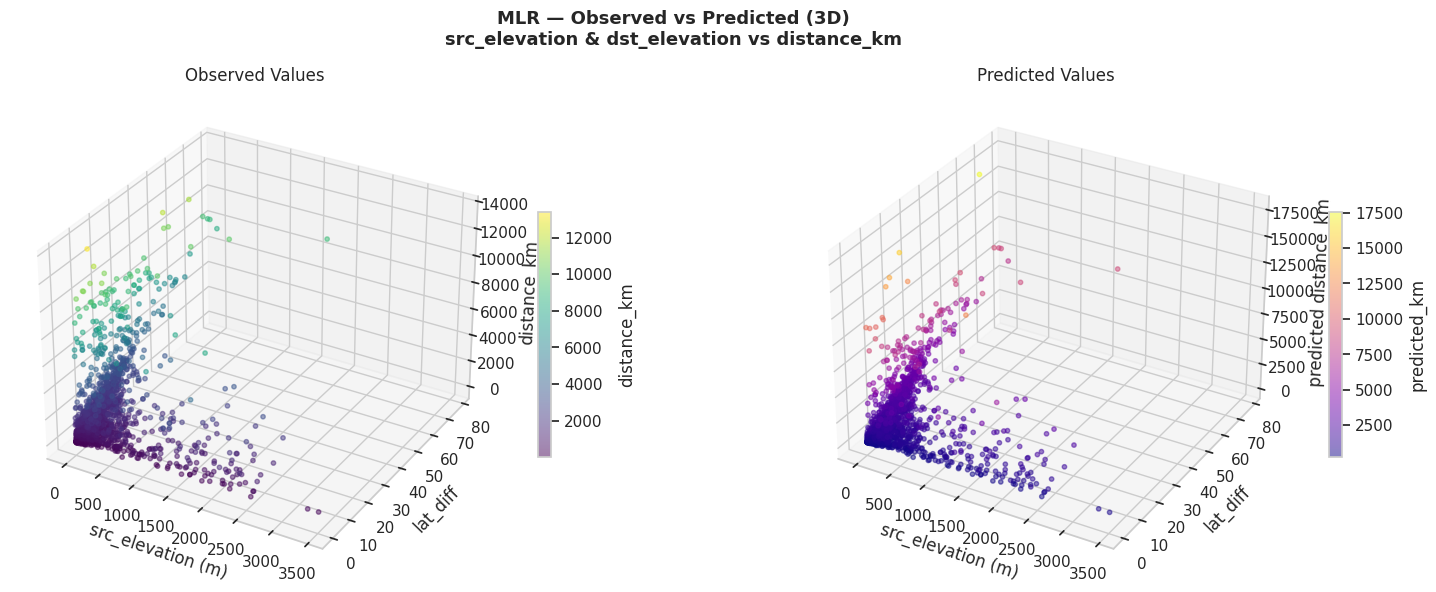

In [62]:
# ── 3D Plot: src_elevation & lat_diff vs distance_km ──────────────────
sample_idx = np.random.choice(len(X_mlr_test), size=min(2000, len(X_mlr_test)), replace=False)
X_plot     = X_mlr_test[sample_idx]
y_obs      = y_mlr_test[sample_idx]
y_pred_plot = y_mlr_pred[sample_idx]

# src_elevation = index 0, lat_diff = index 2
elev_src = X_plot[:, 0]
lat      = X_plot[:, 2]
fig = plt.figure(figsize=(16, 6))

# Subplot 1: Observed
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(elev_src, lat, y_obs,
                  c=y_obs, cmap='viridis', alpha=0.5, s=10)
ax1.set_xlabel('src_elevation (m)')
ax1.set_ylabel('lat_diff')
ax1.set_zlabel('distance_km')
ax1.set_title('Observed Values')
fig.colorbar(sc1, ax=ax1, shrink=0.5, label='distance_km')

# Subplot 2: Predicted
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(elev_src, lat, y_pred_plot,
                  c=y_pred_plot, cmap='plasma', alpha=0.5, s=10)
ax2.set_xlabel('src_elevation (m)')
ax2.set_ylabel('lat_diff')
ax2.set_zlabel('predicted distance_km')
ax2.set_title('Predicted Values')
fig.colorbar(sc2, ax=ax2, shrink=0.5, label='predicted_km')

fig.suptitle('MLR — Observed vs Predicted (3D)\nsrc_elevation & dst_elevation vs distance_km',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [63]:
# ── Loss functions ─────────────────────────────────────────────────────────
mlr_mse  = mean_squared_error(y_mlr_test, y_mlr_pred)
mlr_rmse = np.sqrt(mlr_mse)
mlr_mae  = mean_absolute_error(y_mlr_test, y_mlr_pred)
mlr_r2   = r2_score(y_mlr_test, y_mlr_pred)

print('MLR Loss Functions')
print(f'  MSE  : {mlr_mse:>12,.2f}')
print(f'  RMSE : {mlr_rmse:>12,.2f}')
print(f'  MAE  : {mlr_mae:>12,.2f}')
print(f'  R²   : {mlr_r2:>12,.4f}')

MLR Loss Functions
  MSE  :   610,812.53
  RMSE :       781.54
  MAE  :       345.35
  R²   :       0.8468


**Interpretation of Results**

Adding lat/lon differences alongside both elevation features significantly improves R² (0.8468) compared to SLR (0.0048).

The sign change on src_elevation between the simple and multiple regression models is a natural consequence of adding new features, not a sign of problematic multicollinearity — the VIF scores for all four features fall between 1.2 and 1.4, confirming that the features are largely independent of each other. In the simple model, src_elevation was the only predictor, so it unintentionally absorbed some geographic variation alongside its own effect. Once lat_diff and lon_diff were introduced, they took over the geographic explanation, leaving src_elevation to reflect only its own small, isolated effect on route distance — which settles at +0.016, a practically negligible value. This is precisely why incorporating latitude and longitude as supporting features is necessary — it allows elevation's true contribution to be studied in its proper geographic context, rather than as a mixed signal.

## 2.3 Logistic Regression

**Project Goal**: Route Type Analysis: Classify airlines as primarily domestic or international based on their route portfolios.

The Question: Can we predict whether a route is international or domestic, based on elevation and distance?

LogisticRegression to classify whether a flight route
is international (crossing a country border) or domestic (within the same country).  The target variable is_international is binary: 1 for international and 0 for domestic. The features used are src_elevation, dst_elevation, and distance_km — keeping elevation as the central focus while distance provides additional discriminative signal. Features are standardised using StandardScaler before fitting, as logistic regression is sensitive to feature scale. erformance is reported using absolute loss and log loss, and results are visualised through a predicted probability distribution and a
scatter plot coloured by predicted class.

In [64]:
# ── Data preparation ───────────────────────────────────────────────────────
log_features = ['src_elevation', 'dst_elevation', 'distance_km']
log_data = master_df[log_features + ['is_international']].dropna()

X_log = log_data[log_features].values
y_log = log_data['is_international'].values

X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42, stratify=y_log
)

# Scale (important for logistic regression)
scaler = StandardScaler()
X_log_train_sc = scaler.fit_transform(X_log_train)
X_log_test_sc  = scaler.transform(X_log_test)

# ── Model ──────────────────────────────────────────────────────────────────
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_log_train_sc, y_log_train)

y_log_pred       = log_model.predict(X_log_test_sc)
y_log_pred_proba = log_model.predict_proba(X_log_test_sc)[:, 1]

print('Logistic Regression: src_elevation + dst_elevation + distance_km → is_international')
print(f'  Accuracy: {np.mean(y_log_pred == y_log_test):.4f}')
print('\n  Coefficients:')
for feat, coef in zip(log_features, log_model.coef_[0]):
    print(f'    {feat:<20}: {coef:.4f}')

Logistic Regression: src_elevation + dst_elevation + distance_km → is_international
  Accuracy: 0.7239

  Coefficients:
    src_elevation       : -0.2288
    dst_elevation       : -0.2227
    distance_km         : 1.9611


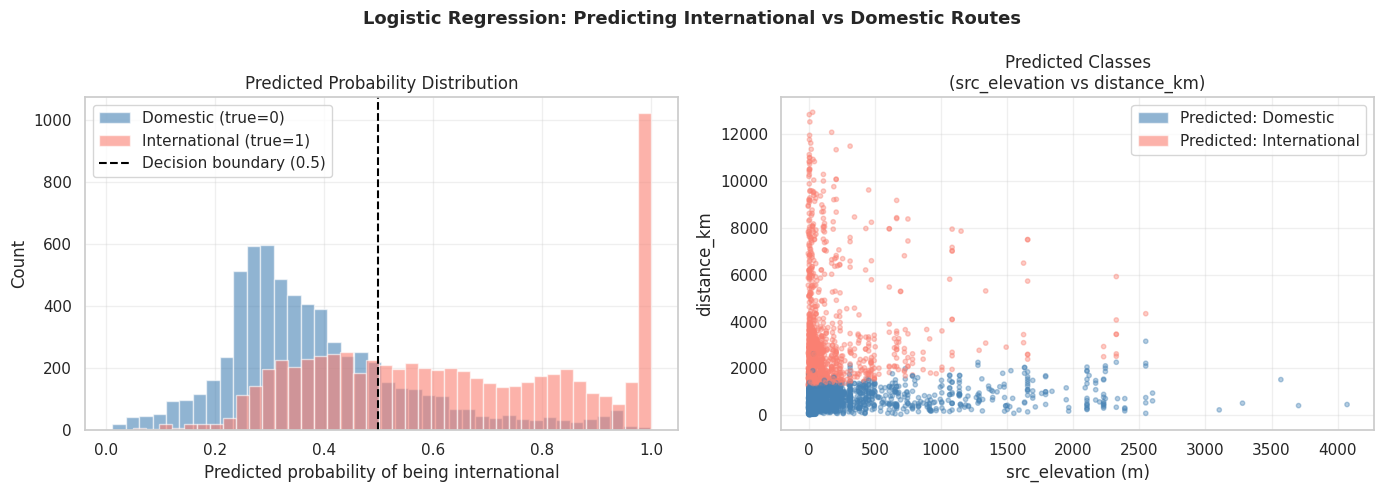

In [65]:
# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: predicted probability distribution by true class
ax1 = axes[0]
ax1.hist(y_log_pred_proba[y_log_test == 0], bins=40, alpha=0.6,
         color='steelblue', label='Domestic (true=0)')
ax1.hist(y_log_pred_proba[y_log_test == 1], bins=40, alpha=0.6,
         color='salmon', label='International (true=1)')
ax1.axvline(0.5, color='black', linestyle='--', linewidth=1.5,
            label='Decision boundary (0.5)')
ax1.set_xlabel('Predicted probability of being international')
ax1.set_ylabel('Count')
ax1.set_title('Predicted Probability Distribution')
ax1.legend()
ax1.grid(alpha=0.3)

# Right: src_elevation vs distance_km coloured by predicted class
ax2 = axes[1]
sample_size = min(3000, len(y_log_test))
idx = np.random.choice(len(y_log_test), size=sample_size, replace=False)
colors = ['steelblue' if p == 0 else 'salmon' for p in y_log_pred[idx]]
ax2.scatter(X_log_test[idx, 0], X_log_test[idx, 2],   # src_elevation vs distance_km
            c=colors, alpha=0.4, s=10)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', alpha=0.6, label='Predicted: Domestic'),
    Patch(facecolor='salmon',    alpha=0.6, label='Predicted: International')
]
ax2.legend(handles=legend_elements)
ax2.set_xlabel('src_elevation (m)')
ax2.set_ylabel('distance_km')
ax2.set_title('Predicted Classes\n(src_elevation vs distance_km)')
ax2.grid(alpha=0.3)

plt.suptitle('Logistic Regression: Predicting International vs Domestic Routes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [66]:
# ── Loss functions ─────────────────────────────────────────────────────────
abs_loss = 1 - np.mean(y_log_pred == y_log_test)
ll       = log_loss(y_log_test, y_log_pred_proba)

print('Logistic Regression Loss Functions')
print(f'  Absolute loss (1 − accuracy): {abs_loss:.4f}')
print(f'  Log loss                    : {ll:.4f}')
print(f'  Accuracy                    : {1 - abs_loss:.4f}')

Logistic Regression Loss Functions
  Absolute loss (1 − accuracy): 0.2761
  Log loss                    : 0.5476
  Accuracy                    : 0.7239


**Interpretation of Results**

Even with only elevation and distance as predictors, the logistic model classifies domestic vs international routes at a reasonable accuracy (0.7239). The distance_km coefficient is strongly positive — longer routes are more likely to be international. Both elevation features carry negative coefficients, meaning high-elevation airports lean toward domestic service, consistent with what we observed in the regression models. This reinforces the infrastructure story: high-altitude airports, often in mountainous or landlocked regions, tend to serve local rather than international traffic.

## Conclusion

The single linear regression showed us that airport elevation alone is a poor
predictor of route distance, with an R² of just 0.0048. This was an expected but important finding — it confirmed that altitude by itself carries very little information about how far a flight travels. The key takeaway is that elevation shapes route behavior indirectly, as a geographic constraint rather than a direct driver.

The real insight came when geographic features were added incorporating latitude and longitude differences between source and destination airports, the multiple linear regression model jumped to an R² of 0.8468, demonstrating that the angular separation between two airports is far more predictive of route distance than the elevation of either one.

The logistic regression further extended this by showing that elevation and distance together can classify domestic versus international routes at 72% accuracy, suggesting that the physical characteristics of a route carry enough signal to distinguish its type even without any airline or schedule information.

# 3. Evaluate Model Performance

During the regression section, all three models
were assessed using a single train-test split (80% training, 20% testing).
While this gives an initial indication of model performance, it carries a
risk — the result may be influenced by which specific rows happened to land
in the test set. In this section, we apply more rigorous evaluation techniques
to verify that our regression results are stable, generalizable, and trustworthy. This is where Model Evaluaiton comes in.

## 3.1 Cross-Validation Techniques

### 3.1.1 Cross-Validation — Simple Linear Regression

Apply 10-fold cross-validation to the Simple Linear
Regression model (src_elevation → distance_km). The dataset is divided into 10 equal folds; each fold takes a turn as the test  set while the remaining 9 folds are used for training. MSE, RMSE, and MAE are  reported as averages across all 10 folds alongside their standard deviations.

In [67]:
# ── Data ───────────────────────────────────────────────────────────────────
slr_cv_data = master_df[['src_elevation', 'distance_km']].dropna()
X_slr_cv    = slr_cv_data[['src_elevation']].values
y_slr_cv    = slr_cv_data['distance_km'].values

# ── 10-Fold Cross Validation ───────────────────────────────────────────────
kf         = KFold(n_splits=10, shuffle=True, random_state=42)
slr_cv_r2  = cross_val_score(LinearRegression(), X_slr_cv, y_slr_cv,
                              cv=kf, scoring='r2')
slr_cv_mse = cross_val_score(LinearRegression(), X_slr_cv, y_slr_cv,
                              cv=kf, scoring='neg_mean_squared_error')
slr_cv_mae = cross_val_score(LinearRegression(), X_slr_cv, y_slr_cv,
                              cv=kf, scoring='neg_mean_absolute_error')

print('SLR — 10-Fold Cross Validation Results')
print(f'  R²   mean: {slr_cv_r2.mean():.4f}  std: {slr_cv_r2.std():.4f}')
print(f'  MSE  mean: {(-slr_cv_mse).mean():,.2f}  std: {(-slr_cv_mse).std():,.2f}')
print(f'  RMSE mean: {np.sqrt(-slr_cv_mse).mean():,.2f}  std: {np.sqrt(-slr_cv_mse).std():,.2f}')
print(f'  MAE  mean: {(-slr_cv_mae).mean():,.2f}  std: {(-slr_cv_mae).std():,.2f}')

print('\nSLR — Comparison: Train-Test Split vs Cross-Validation')
print(f'  Train-Test R²  : {slr_r2:.4f}')
print(f'  Cross-Val R²   : {slr_cv_r2.mean():.4f}  (std: {slr_cv_r2.std():.4f})')
print(f'  Train-Test RMSE: {slr_rmse:,.2f}')
print(f'  Cross-Val RMSE : {np.sqrt(-slr_cv_mse).mean():,.2f}')

SLR — 10-Fold Cross Validation Results
  R²   mean: 0.0046  std: 0.0013
  MSE  mean: 4,083,896.26  std: 163,740.23
  RMSE mean: 2,020.46  std: 40.55
  MAE  mean: 1,352.82  std: 17.79

SLR — Comparison: Train-Test Split vs Cross-Validation
  Train-Test R²  : 0.0048
  Cross-Val R²   : 0.0046  (std: 0.0013)
  Train-Test RMSE: 1,992.16
  Cross-Val RMSE : 2,020.46


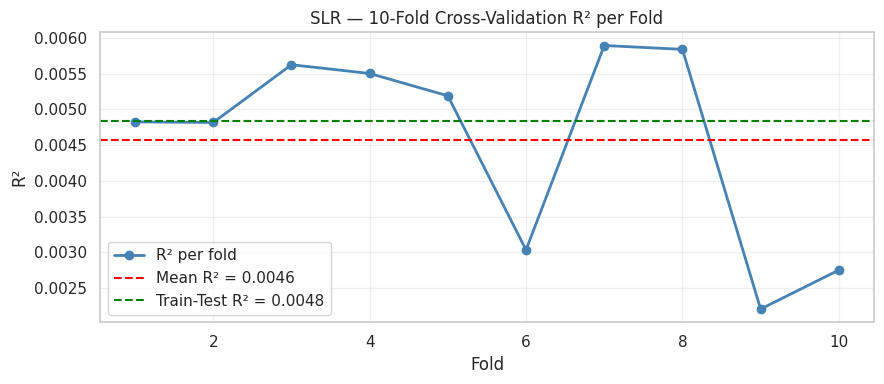

In [68]:
# ── Plot: CV fold scores ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 11), slr_cv_r2, marker='o', color='steelblue',
        linewidth=2, label='R² per fold')
ax.axhline(slr_cv_r2.mean(), color='red', linestyle='--',
           linewidth=1.5, label=f'Mean R² = {slr_cv_r2.mean():.4f}')
ax.axhline(slr_r2, color='green', linestyle='--',
           linewidth=1.5, label=f'Train-Test R² = {slr_r2:.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('R²')
ax.set_title('SLR — 10-Fold Cross-Validation R² per Fold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation of Results**

The 10-fold cross-validation confirms that the weak R² observed in the
train-test split is not a fluke — it is consistent across all 10 folds,
with a small standard deviation indicating stable (though low) performance.
This is itself a meaningful finding: elevation is a consistently poor predictor
of route distance regardless of which subset of data the model trains on.

### 3.1.2 Cross-Validation — Multiple Linear Regression

Apply the same 10-fold cross-validation procedure to the Multiple
Linear Regression model, which uses src_elevation, dst_elevation, lat_diff,
and lon_diff to predict distance_km. The purpose here is to verify that the
strong R² achieved in the train-test split (0.8468) holds consistently across
different data subsets and is not inflated by a favorable split.

In [69]:
# ── Data ───────────────────────────────────────────────────────────────────
mlr_features = ['src_elevation', 'dst_elevation', 'lat_diff', 'lon_diff']
mlr_cv_data  = master_df[mlr_features + ['distance_km']].dropna()
X_mlr_cv     = mlr_cv_data[mlr_features].values
y_mlr_cv     = mlr_cv_data['distance_km'].values

# ── 10-Fold Cross Validation ───────────────────────────────────────────────
mlr_cv_r2  = cross_val_score(LinearRegression(), X_mlr_cv, y_mlr_cv,
                              cv=kf, scoring='r2')
mlr_cv_mse = cross_val_score(LinearRegression(), X_mlr_cv, y_mlr_cv,
                              cv=kf, scoring='neg_mean_squared_error')
mlr_cv_mae = cross_val_score(LinearRegression(), X_mlr_cv, y_mlr_cv,
                              cv=kf, scoring='neg_mean_absolute_error')

print('MLR — 10-Fold Cross Validation Results')
print(f'  R²   mean: {mlr_cv_r2.mean():.4f}  std: {mlr_cv_r2.std():.4f}')
print(f'  MSE  mean: {(-mlr_cv_mse).mean():,.2f}  std: {(-mlr_cv_mse).std():,.2f}')
print(f'  RMSE mean: {np.sqrt(-mlr_cv_mse).mean():,.2f}  std: {np.sqrt(-mlr_cv_mse).std():,.2f}')
print(f'  MAE  mean: {(-mlr_cv_mae).mean():,.2f}  std: {(-mlr_cv_mae).std():,.2f}')

print('\nMLR — Comparison: Train-Test Split vs Cross-Validation')
print(f'  Train-Test R²  : {mlr_r2:.4f}')
print(f'  Cross-Val R²   : {mlr_cv_r2.mean():.4f}  (std: {mlr_cv_r2.std():.4f})')
print(f'  Train-Test RMSE: {mlr_rmse:,.2f}')
print(f'  Cross-Val RMSE : {np.sqrt(-mlr_cv_mse).mean():,.2f}')

MLR — 10-Fold Cross Validation Results
  R²   mean: 0.8445  std: 0.0148
  MSE  mean: 636,565.76  std: 53,680.02
  RMSE mean: 797.14  std: 33.76
  MAE  mean: 349.83  std: 5.66

MLR — Comparison: Train-Test Split vs Cross-Validation
  Train-Test R²  : 0.8468
  Cross-Val R²   : 0.8445  (std: 0.0148)
  Train-Test RMSE: 781.54
  Cross-Val RMSE : 797.14


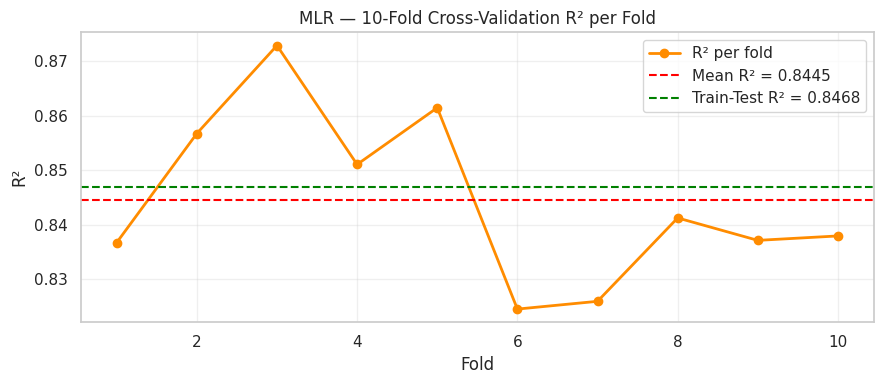

In [70]:
# ── Plot: CV fold scores ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 11), mlr_cv_r2, marker='o', color='darkorange',
        linewidth=2, label='R² per fold')
ax.axhline(mlr_cv_r2.mean(), color='red', linestyle='--',
           linewidth=1.5, label=f'Mean R² = {mlr_cv_r2.mean():.4f}')
ax.axhline(mlr_r2, color='green', linestyle='--',
           linewidth=1.5, label=f'Train-Test R² = {mlr_r2:.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('R²')
ax.set_title('MLR — 10-Fold Cross-Validation R² per Fold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation of Results**

The MLR cross-validation results show a consistently high R² (0.8445) across all 10 folds with a small standard deviation, confirming that the model generalizes well and is not overfitting to the training data. The cross-validation mean R² is close to the train-test split R² (0.8468), which validates that the 80/20 split used in the regression section was representative of the full dataset. Comparing with the SLR
cross-validation results, the improvement remains substantial and consistent,
confirming that the geographic supporting features genuinely contribute to
predicting route distance.

### 3.1.3 Cross-Validation — Logistic Regression

10-fold cross-validation is applied to the Logistic Regression
model, which classifies routes as international or domestic using src_elevation, dst_elevation, and distance_km. Logistic regression is evaluated using accuracy and log loss.

In [71]:
# ── Data ───────────────────────────────────────────────────────────────────
log_features = ['src_elevation', 'dst_elevation', 'distance_km']
log_cv_data  = master_df[log_features + ['is_international']].dropna()
X_log_cv     = log_cv_data[log_features].values
y_log_cv     = log_cv_data['is_international'].values

# Scale first — fit scaler on full data for CV
scaler_cv      = StandardScaler()
X_log_cv_sc    = scaler_cv.fit_transform(X_log_cv)

# ── 10-Fold Cross Validation ───────────────────────────────────────────────
log_cv_acc  = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                               X_log_cv_sc, y_log_cv, cv=kf, scoring='accuracy')
log_cv_ll   = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                               X_log_cv_sc, y_log_cv, cv=kf, scoring='neg_log_loss')

print('Logistic — 10-Fold Cross Validation Results')
print(f'  Accuracy  mean: {log_cv_acc.mean():.4f}  std: {log_cv_acc.std():.4f}')
print(f'  Log Loss  mean: {(-log_cv_ll).mean():.4f}  std: {(-log_cv_ll).std():.4f}')

log_abs_loss = 1 - np.mean(y_log_pred == y_log_test)
print('\nLogistic — Comparison: Train-Test Split vs Cross-Validation')
print(f'  Train-Test Accuracy  : {1 - log_abs_loss:.4f}')
print(f'  Cross-Val Accuracy   : {log_cv_acc.mean():.4f}  (std: {log_cv_acc.std():.4f})')

Logistic — 10-Fold Cross Validation Results
  Accuracy  mean: 0.7234  std: 0.0037
  Log Loss  mean: 0.5490  std: 0.0040

Logistic — Comparison: Train-Test Split vs Cross-Validation
  Train-Test Accuracy  : 0.7239
  Cross-Val Accuracy   : 0.7234  (std: 0.0037)


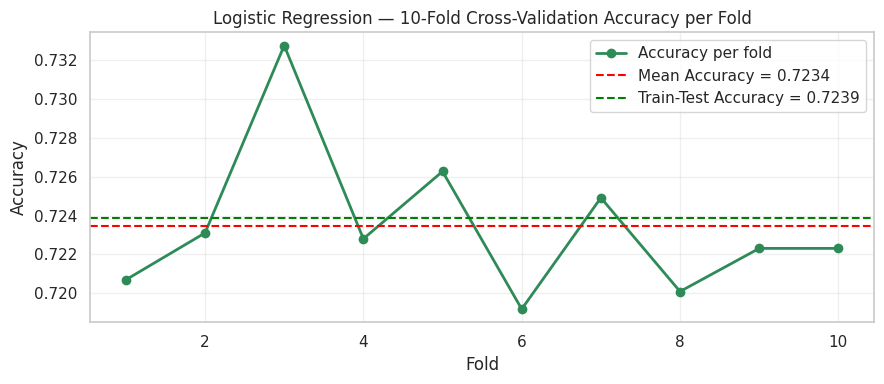

In [72]:
# ── Plot: CV fold scores ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 11), log_cv_acc, marker='o', color='seagreen',
        linewidth=2, label='Accuracy per fold')
ax.axhline(log_cv_acc.mean(), color='red', linestyle='--',
           linewidth=1.5, label=f'Mean Accuracy = {log_cv_acc.mean():.4f}')
ax.axhline(1 - log_abs_loss, color='green', linestyle='--',
           linewidth=1.5, label=f'Train-Test Accuracy = {1-log_abs_loss:.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('Logistic Regression — 10-Fold Cross-Validation Accuracy per Fold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation of Results**

The cross-validation accuracy across 10 folds (0.7234) is close to the train-test split accuracy (0.7239) with small standard deviation, confirming the logistic model is stable and not sensitive to which specific data subset it trains on. The model intentionally uses only elevation and distance as predictors, keeping the focus on infrastructure-related features. The result confirms that elevation carries a meaningful but limited signal for distinguishing domestic from international routes — high-elevation airports lean slightly toward domestic service, but route type is ultimately determined by a broader set of factors beyond what elevation alone can capture.

## 3.2 Bootstrap Method

The bootstrap method is applied to the MLR model, which was selected as the best-performing model based on its cross-validation R². Bootstrap resampling draws 1000 random samples with replacement from the full dataset — meaning the same row can appear multiple times in a single sample. The mean and standard deviation of this distribution are reported, along with a 95% confidence interval, to quantify how stable and reliable the model's error estimate is.

In [73]:
# ── Bootstrap on MLR ───────────────────────────────────────────────────────
mlr_boot_data = master_df[mlr_features + ['distance_km']].dropna()
X_boot        = mlr_boot_data[mlr_features].values
y_boot        = mlr_boot_data['distance_km'].values

n_iterations  = 1000
boot_rmse     = []

for i in range(n_iterations):
    # Resample with replacement
    X_bs, y_bs = resample(X_boot, y_boot, random_state=i)

    # Train on bootstrap sample, test on out-of-bag (original data)
    model_bs   = LinearRegression()
    model_bs.fit(X_bs, y_bs)
    y_bs_pred  = model_bs.predict(X_boot)
    rmse_bs    = np.sqrt(mean_squared_error(y_boot, y_bs_pred))
    boot_rmse.append(rmse_bs)

boot_rmse = np.array(boot_rmse)

print('Bootstrap Results — Multiple Linear Regression (1000 iterations)')
print(f'  RMSE Mean : {boot_rmse.mean():,.2f}')
print(f'  RMSE Std  : {boot_rmse.std():,.2f}')
print(f'  RMSE 95% CI: [{np.percentile(boot_rmse, 2.5):,.2f}, '
      f'{np.percentile(boot_rmse, 97.5):,.2f}]')

Bootstrap Results — Multiple Linear Regression (1000 iterations)
  RMSE Mean : 797.69
  RMSE Std  : 0.42
  RMSE 95% CI: [797.35, 798.87]


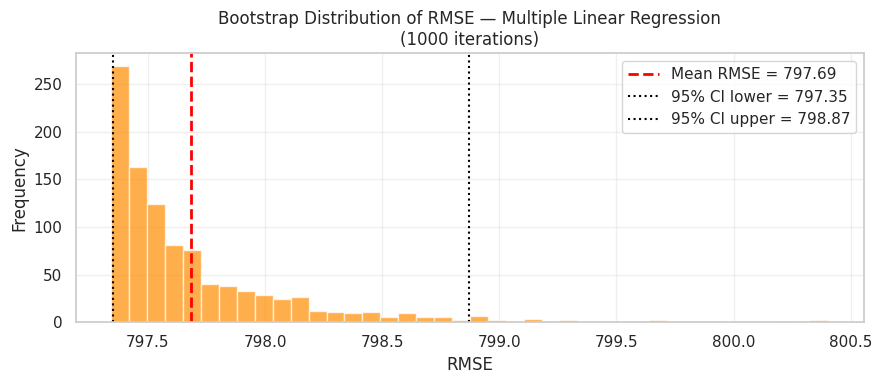

In [74]:
# ── Plot: Bootstrap RMSE distribution ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(boot_rmse, bins=40, color='darkorange', alpha=0.7, edgecolor='white')
ax.axvline(boot_rmse.mean(), color='red', linestyle='--',
           linewidth=2, label=f'Mean RMSE = {boot_rmse.mean():,.2f}')
ax.axvline(np.percentile(boot_rmse, 2.5), color='black', linestyle=':',
           linewidth=1.5, label=f'95% CI lower = {np.percentile(boot_rmse, 2.5):,.2f}')
ax.axvline(np.percentile(boot_rmse, 97.5), color='black', linestyle=':',
           linewidth=1.5, label=f'95% CI upper = {np.percentile(boot_rmse, 97.5):,.2f}')
ax.set_xlabel('RMSE')
ax.set_ylabel('Frequency')
ax.set_title('Bootstrap Distribution of RMSE — Multiple Linear Regression\n(1000 iterations)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation of Results**

The bootstrap analysis over 1000 iterations produces a Mean RMSE of 797.69 km
with a very small standard deviation of 0.42 km. This indicates that the MLR
model's error estimate is highly stable — across 1000 different random resamples of the dataset, the model's prediction error barely fluctuates.

The 95% confidence interval [797.35, 798.87] is extremely narrow, spanning
only about 1.5 km. This means we can be 95% confident that the true prediction
error of the model falls within this tight range. The histogram visualizes this stability — the distribution is right-skewed with the vast
majority of RMSE values concentrated near the mean of 797.69, while only a
small number of resamples produced slightly higher errors

Overall, the bootstrap results strongly validate the reliability of the MLR
model.

## 3.3 Model Comparison — Adjusted R² and One-Standard-Error

Compare the SLR and MLR models using two methods.
- Adjusted R² is used to account for the difference in the number of features between the two models — since adjusted R² penalizes unnecessary complexity.
- One-standard-error rule is applied to the cross-validation RMSE
results to determine whether the added complexity of MLR is genuinely justified, or whether SLR performs within an acceptable margin of the best model. Logistic regression is excluded from this comparison as it solves a different task (classification).

1-SE threshold Explanation: The threshold is calculated as the best model's mean RMSE plus one standard error. It acts as a boundary — if a simpler model's RMSE falls within this boundary, its performance is considered close enough to the best model that the added complexity is not worth it. If it falls outside, the more complex model is the clear winner.

In [75]:
# ── Adjusted R² ────────────────────────────────────────────────────────────
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

n_slr = len(y_slr_test)
n_mlr = len(y_mlr_test)

adj_r2_slr = adjusted_r2(slr_r2, n_slr, 1)   # 1 feature
adj_r2_mlr = adjusted_r2(mlr_r2, n_mlr, 4)   # 4 features

print('Adjusted R² Comparison')
print(f'  SLR — R²: {slr_r2:.4f}  Adjusted R²: {adj_r2_slr:.4f}  (1 feature)')
print(f'  MLR — R²: {mlr_r2:.4f}  Adjusted R²: {adj_r2_mlr:.4f}  (4 features)')

# ── One-Standard-Error Rule ─────────────────────────────────────────────────
slr_cv_rmse = np.sqrt(-slr_cv_mse)
mlr_cv_rmse = np.sqrt(-mlr_cv_mse)

slr_mean_rmse = slr_cv_rmse.mean()
slr_se_rmse   = slr_cv_rmse.std() / np.sqrt(10)
mlr_mean_rmse = mlr_cv_rmse.mean()
mlr_se_rmse   = mlr_cv_rmse.std() / np.sqrt(10)

print('\nOne-Standard-Error Rule (CV RMSE)')
print(f'  SLR — Mean RMSE: {slr_mean_rmse:,.2f}  SE: {slr_se_rmse:,.2f}'
      f'  Range: [{slr_mean_rmse - slr_se_rmse:,.2f}, {slr_mean_rmse + slr_se_rmse:,.2f}]')
print(f'  MLR — Mean RMSE: {mlr_mean_rmse:,.2f}  SE: {mlr_se_rmse:,.2f}'
      f'  Range: [{mlr_mean_rmse - mlr_se_rmse:,.2f}, {mlr_mean_rmse + mlr_se_rmse:,.2f}]')

best_rmse     = min(slr_mean_rmse, mlr_mean_rmse)
threshold     = best_rmse + slr_se_rmse  # 1-SE threshold from best model
print(f'\n  Best RMSE     : {best_rmse:,.2f}')
print(f'  1-SE Threshold: {threshold:,.2f}')
print(f'  SLR within threshold? {"Yes" if slr_mean_rmse <= threshold else "No"}')
print(f'  MLR within threshold? {"Yes" if mlr_mean_rmse <= threshold else "No"}')

Adjusted R² Comparison
  SLR — R²: 0.0048  Adjusted R²: 0.0048  (1 feature)
  MLR — R²: 0.8468  Adjusted R²: 0.8468  (4 features)

One-Standard-Error Rule (CV RMSE)
  SLR — Mean RMSE: 2,020.46  SE: 12.82  Range: [2,007.64, 2,033.28]
  MLR — Mean RMSE: 797.14  SE: 10.68  Range: [786.46, 807.81]

  Best RMSE     : 797.14
  1-SE Threshold: 809.96
  SLR within threshold? No
  MLR within threshold? Yes


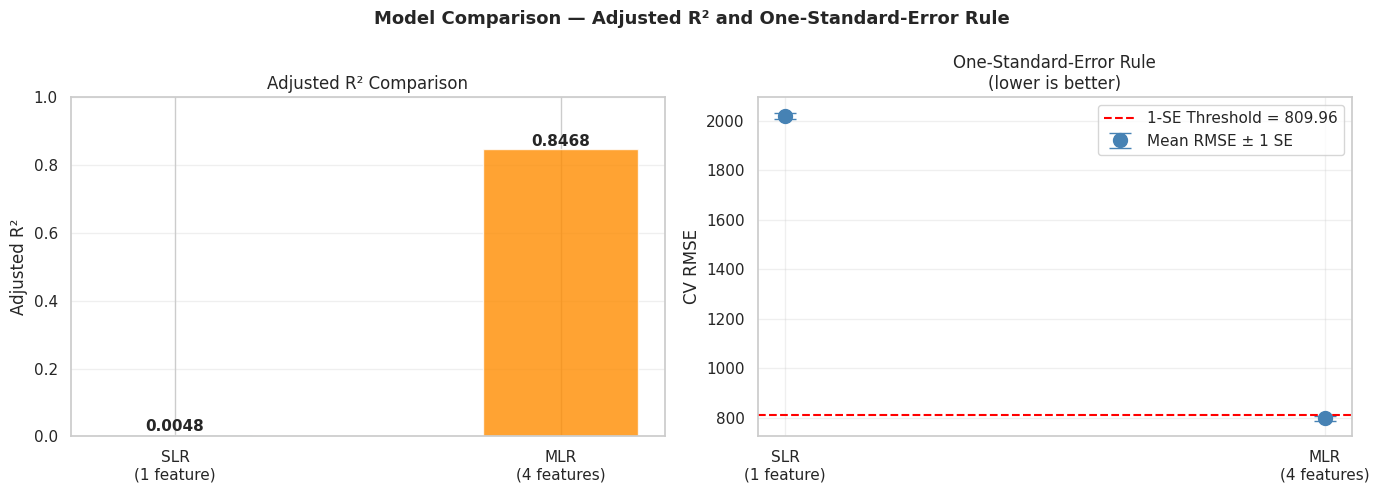

In [76]:
# ── Plot: Model Comparison ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Adjusted R² bar chart
ax1 = axes[0]
models    = ['SLR\n(1 feature)', 'MLR\n(4 features)']
adj_r2s   = [adj_r2_slr, adj_r2_mlr]
colors    = ['steelblue', 'darkorange']
bars      = ax1.bar(models, adj_r2s, color=colors, alpha=0.8, edgecolor='white', width=0.4)
for bar, val in zip(bars, adj_r2s):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax1.set_ylabel('Adjusted R²')
ax1.set_title('Adjusted R² Comparison')
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

# Right: One-standard-error plot
ax2 = axes[1]
means = [slr_mean_rmse, mlr_mean_rmse]
ses   = [slr_se_rmse,   mlr_se_rmse]
ax2.errorbar(models, means, yerr=ses, fmt='o', color='steelblue',
             markersize=10, capsize=8, linewidth=2, label='Mean RMSE ± 1 SE')
ax2.axhline(best_rmse + slr_se_rmse, color='red', linestyle='--',
            linewidth=1.5, label=f'1-SE Threshold = {best_rmse + slr_se_rmse:,.2f}')
ax2.set_ylabel('CV RMSE')
ax2.set_title('One-Standard-Error Rule\n(lower is better)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Model Comparison — Adjusted R² and One-Standard-Error Rule',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation of Results**

The adjusted R² comparison confirms that the improvement from SLR (0.0048)to MLR (0.8468) is genuine — the additional features (dst_elevation, lat_diff, lon_diff) contribute meaningful predictive power beyond what elevation alone provides, and the increase in adjusted R² is not simply a result of adding more variables. The one-standard-error rule further supports MLR as the preferred model — SLR's cross-validation RMSE does not fall within one standard error of MLR's best performance, meaning the
simpler model is not good enough and the added complexity of MLR is fully justified.

## Conclusion

The cross-validation and bootstrap analysis confirmed and strengthened the
findings from the regression section. Running 10-fold cross-validation on all
three models showed that their performance metrics were stable and consistent
across folds, ruling out the possibility that the train-test split results were
a product of lucky data splitting. The weak R² of SLR held consistently across
all 10 folds, and so did the strong R² of MLR, which means both results
genuinely reflect the underlying relationships in the data rather than
overfitting or coincidence.

The bootstrap analysis on the MLR model produced a mean RMSE of 797.69 km
with a standard deviation of just 0.42 km across 1,000 iterations, which is
a strong indicator of model stability. The adjusted R² comparison and the
one-standard-error rule together confirmed that the additional features in
MLR contribute genuine predictive value rather than just complexity. Based on
all four evaluation methods, the Multiple Linear Regression is the strongest
and most reliable model in this project, and the evaluation section gave us
confidence that it generalizes well beyond the training data.

# 4. Supervised Learning

For the supervised learning component, we apply a Support Vector Machine (SVM)
to classify flight routes as either domestic or international. SVM is chosen
because it is well-suited for binary classification tasks where the goal is to
find a clear decision boundary between two classes. Unlike KNN, which becomes
computationally expensive on large datasets, and Naive Bayes, which assumes
feature independence, SVM handles correlated and mixed features more effectively, making it a better fit for this dataset.

## 4.1 Support Vector Machine (SVM)

In this section, we apply a Support Vector Machine (SVM) to classify flight routes
as domestic or international. SVM works by finding the optimal hyperplane that best
separates the two classes in the feature space. We use distance_km, geographic
coordinates, elevation, stops, airport type, and continent as features, since these
are the most relevant variables for distinguishing domestic from international routes.

In [77]:
# ── Create target variable ────────────────────────────────────────────────
master_df_svm = master_df.dropna(subset=['src_country', 'dst_country']).copy()
master_df_svm['is_domestic'] = (
    master_df_svm['src_country'] == master_df_svm['dst_country']
).astype(int)

# ── Select features ───────────────────────────────────────────────────────
features = ['distance_km', 'src_lat', 'src_lon', 'dst_lat', 'dst_lon',
            'src_elevation', 'dst_elevation', 'stops',
            'src_airport_type', 'dst_airport_type',
            'src_continent', 'dst_continent']

X = master_df_svm[features].copy()
y = master_df_svm['is_domestic']

# ── Encode categorical features ───────────────────────────────────────────
le = LabelEncoder()
for col in ['src_airport_type', 'dst_airport_type', 'src_continent', 'dst_continent']:
    X[col] = le.fit_transform(X[col])

# ── Scale features ────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Train/test split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training set size : {X_train.shape[0]} rows")
print(f"Testing set size  : {X_test.shape[0]} rows")
print(f"\nClass distribution in target:")
print(y.value_counts().rename({0: 'International', 1: 'Domestic'}))

Training set size : 53102 rows
Testing set size  : 13276 rows

Class distribution in target:
is_domestic
International    33785
Domestic         32593
Name: count, dtype: int64


In [78]:
# ── Train SVM model ───────────────────────────────────────────────────────
svm_model = LinearSVC(max_iter=2000, random_state=42)
svm_model.fit(X_train, y_train)

# ── Predictions ───────────────────────────────────────────────────────────
y_pred = svm_model.predict(X_test)

# ── Evaluation ────────────────────────────────────────────────────────────
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['International', 'Domestic']))

Accuracy: 0.7404

Classification Report:
               precision    recall  f1-score   support

International       0.76      0.72      0.74      6834
     Domestic       0.72      0.76      0.74      6442

     accuracy                           0.74     13276
    macro avg       0.74      0.74      0.74     13276
 weighted avg       0.74      0.74      0.74     13276



**Interpretation of Results**

The SVM model achieves an overall accuracy of 74%, correctly classifying 3 out
of 4 routes. Both classes perform consistently, with precision and recall scores sitting around 0.72–0.76 for both international and domestic routes, indicating that the model does not significantly favour one class over the other. The macro average F1-score of 0.74 further confirms this balance.

These results suggest that the geographic and infrastructure features used — such as distance, coordinates, airport type, and continent — carry meaningful signal for distinguishing domestic from international routes, though the remaining 26% misclassification rate indicates that some routes share overlapping characteristics regardless of their type.

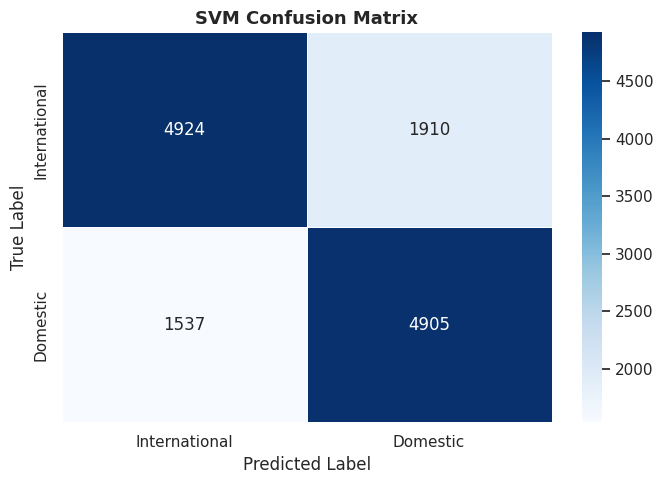

In [79]:
# ── Plot confusion matrix ─────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['International', 'Domestic'],
            yticklabels=['International', 'Domestic'],
            linewidths=0.5, ax=ax)
ax.set_title('SVM Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

**Interpretation of Results**

The confusion matrix shows the breakdown of correct and incorrect predictions
across both classes. The model correctly identified 4,924 international routes
and 4,905 domestic routes, which form the diagonal of the matrix and represent
the majority of predictions. On the other hand, 1,910 international routes were
incorrectly predicted as domestic, and 1,537 domestic routes were incorrectly
predicted as international. The misclassification is fairly balanced between both classes, which is consistent with the similar precision and recall scores seen in the classification report.

## 4.2 SVM Decision Boundary Visualization

Since SVM operates across 12 features, the decision boundary cannot be plotted
directly. To visualize it, we use Principal Component Analysis (PCA) to compress the 12 features down to 2 dimensions, then refit the SVM on these 2 components and plot the resulting boundary. It is important to note that
this plot serves as a visual approximation rather than an exact representation
of the full model.

Variance explained by PC1     : 25.94%
Variance explained by PC2     : 17.20%
Total variance explained      : 43.14%


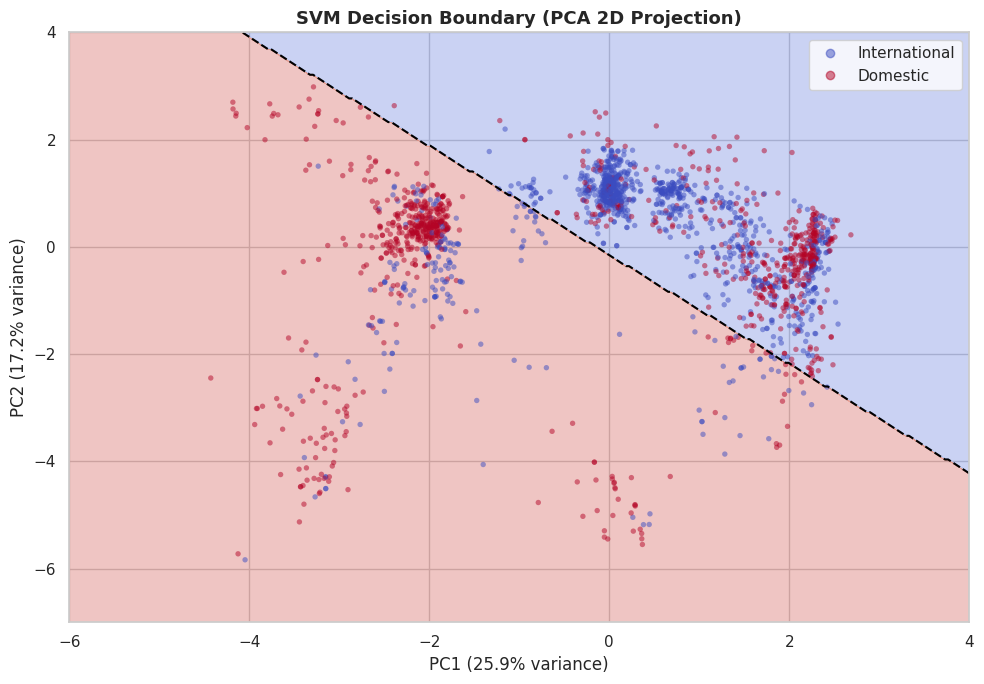

In [80]:
# ── Reduce to 2D using PCA ────────────────────────────────────────────────
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by PC1     : {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2     : {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance explained      : {pca.explained_variance_ratio_.sum():.2%}")

# ── Refit SVM on 2 PCA components ────────────────────────────────────────
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)
svm_pca = LinearSVC(max_iter=2000, random_state=42)
svm_pca.fit(X_train_pca, y_train_pca)

# ── Create decision boundary mesh ─────────────────────────────────────────
xx, yy = np.meshgrid(np.linspace(-6, 4, 300), np.linspace(-7, 4, 300))
Z = svm_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# ── Sample 2000 points for scatter (avoid overplotting) ───────────────────
np.random.seed(42)
idx = np.random.choice(len(X_pca), 2000, replace=False)
X_sample = X_pca[idx]
y_sample = y.values[idx]

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
ax.contour(xx, yy, Z, levels=[0.5], colors='black',
           linewidths=1.5, linestyles='--')
scatter = ax.scatter(X_sample[:, 0], X_sample[:, 1],
                     c=y_sample, cmap='coolwarm',
                     alpha=0.5, s=15, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('SVM Decision Boundary (PCA 2D Projection)', fontsize=13, fontweight='bold')
ax.legend(handles=scatter.legend_elements()[0],
          labels=['International', 'Domestic'], loc='upper right')
plt.tight_layout()
plt.show()

**Interpretation of Results**

PC1 captures 25.9% of the variance and PC2 captures 17.2%, giving a combined
explanation of 43.14% of the total variance in the data. The dashed black line
represents the decision boundary — the hyperplane that the SVM learned to
separate domestic from international routes. Points on the red side are
predicted as domestic, while points on the blue side are predicted as
international.

The considerable overlap between the two classes in the plot is expected
for two reasons. First, compressing 12 dimensions down to 2 loses a significant
amount of information, so routes that are separable in the full feature space
may appear mixed here. Second, some domestic and international routes genuinely
share similar geographic and infrastructure characteristics, which is reflected
in the 26% misclassification rate of the full model.

## Conclusion

Applying SVM to classify domestic and international routes taught us that
geographic and infrastructure features alone can predict route type with
reasonable accuracy. A 74% accuracy suggests that the physical characteristics of a route — how far it travels, where it originates, and what type of airports
it connects — already carry enough signal to distinguish domestic from
international travel in most cases.

What was perhaps most interesting is how balanced the model performed across
both classes. The similar precision and recall scores suggest that
domestic and international routes are equally challenging to distinguish from
a purely geographic perspective. The 26% misclassification rate also raises an interesting question — these are routes that look international but are domestic, or vice versa.

# 5. Unsupervised Learning

## 5.1 K-Means Clustering

The Question: Can airports be grouped into meaningful categories based purely on their geographic and operational characteristics, without using any predefined labels?

Apply K-Means clustering to group airports based on their
operational characteristics. Rather than working at the route level, we aggregate the data at the airport level, capturing each airport's geographic position, elevation, number of routes, average route distance, number of unique destinations, and number of continents served. The goal is to discover whether airports naturally group into meaningful categories based on these features, without using any predefined labels.

In [81]:
# ── Aggregate data at airport level ──────────────────────────────────────
airport_df = master_df.groupby('src_iata').agg(
    lat=('src_lat', 'first'),
    lon=('src_lon', 'first'),
    elevation=('src_elevation', 'first'),
    route_count=('dst_iata', 'count'),
    avg_distance=('distance_km', 'mean'),
    unique_destinations=('dst_iata', 'nunique'),
    unique_continents=('dst_continent', 'nunique')
).reset_index()

print(f"Total airports: {len(airport_df)}")
print("\nAirport feature summary:")
print(airport_df[['route_count','avg_distance','unique_destinations','unique_continents']].describe().round(2))

Total airports: 3375

Airport feature summary:
       route_count  avg_distance  unique_destinations  unique_continents
count      3375.00       3375.00              3375.00            3375.00
mean         19.67        784.21                10.89               1.32
std          53.18        726.79                23.95               0.75
min           1.00          3.00                 1.00               1.00
25%           2.00        265.95                 1.00               1.00
50%           4.00        569.75                 3.00               1.00
75%          11.00       1069.64                 8.00               1.00
max         915.00       5581.00               236.00               6.00


**Interpretation of Results**

The dataset contains 3,375 unique source airports. The route count per airport
ranges widely, from 1 to 236 routes, with a mean of around 11 unique destinations per airport. Most airports serve only 1 continent, while a small number reach up to 6, indicating that the majority of airports operate regionally. This spread across features suggests that airports are likely to form distinct groups based on their operational scale.

To determine the best value of k, we use two methods. The elbow method plots
inertia against k, where inertia measures how tightly data points are grouped
within each cluster — a lower value is better. The silhouette score measures
how well each point fits its own cluster compared to neighboring clusters,
where a higher score indicates better-defined clusters.

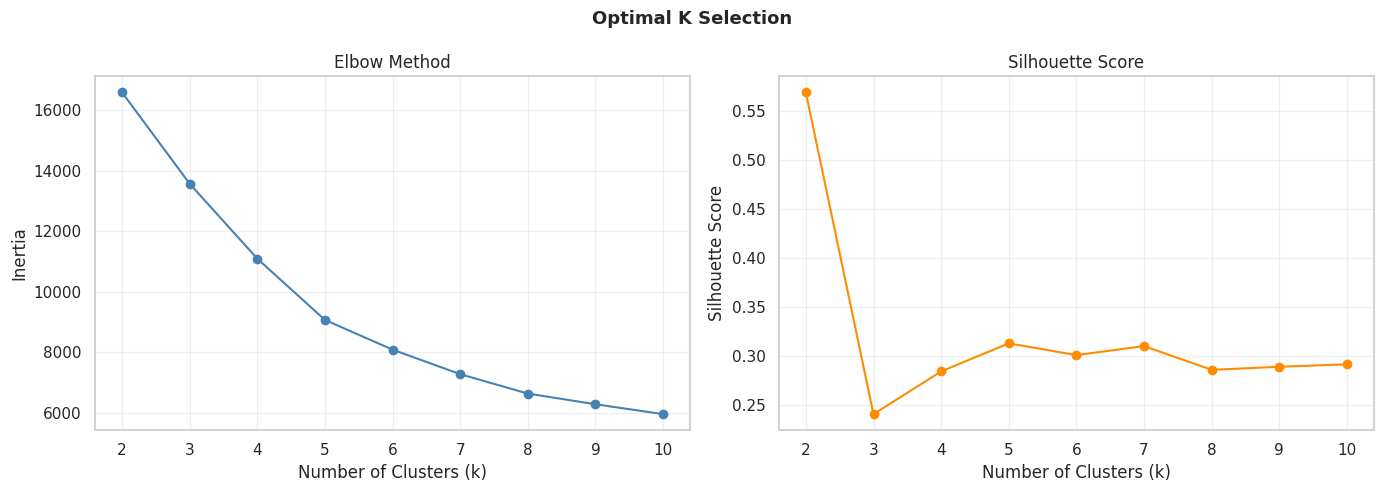

In [82]:
# ── Scale features ────────────────────────────────────────────────────────
features_cluster = ['lat', 'lon', 'elevation', 'route_count',
                    'avg_distance', 'unique_destinations', 'unique_continents']

scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(airport_df[features_cluster])

# ── Elbow and silhouette scores for k=2 to 10 ────────────────────────────
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_km)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_km, labels))

# ── Plot elbow and silhouette ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimal K Selection', fontsize=13, fontweight='bold')

axes[0].plot(k_range, inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(k_range, silhouettes, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation of Results**

The elbow plot does not show a sharp bend, meaning there is no single
dominant k that stands out. The inertia decreases gradually and begins
to flatten from k=5 onwards. The silhouette score is highest at k=2
(0.57), but drops sharply at k=3 before stabilizing around 0.28–0.31
from k=4 onward with no meaningful improvement. While k=2 produces the
most statistically separated clusters, it is too broad to be analytically
useful. We therefore select k=4 as it sits at the point where inertia
starts to level off and produces cluster groupings that are meaningful
and interpretable in the context of airport operations.

Fit the K-Means model using k=4 and assign each airport to its
corresponding cluster. The clustering is based on a combination of geographic
features — latitude, longitude, and elevation — alongside operational features
such as route count, average distance, unique destinations, and continents served.

In [83]:
# ── Fit K-Means with k=4 ─────────────────────────────────────────────────
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
airport_df['cluster'] = kmeans.fit_predict(X_km)

# ── Full cluster profile including geographic features ────────────────────
cluster_profile = airport_df.groupby('cluster')[
    ['lat', 'lon', 'elevation', 'route_count',
     'avg_distance', 'unique_destinations', 'unique_continents']
].mean().round(2)

print("Cluster profiles:")
print(cluster_profile)
print("\nAirports per cluster:")
print(airport_df['cluster'].value_counts().sort_index())

Cluster profiles:
           lat    lon  elevation  route_count  avg_distance  \
cluster                                                       
0        42.35 -69.58     198.10         5.93        474.83   
1         4.86  72.27     453.37         6.18        590.93   
2        36.37   3.93     210.22       274.58       2524.40   
3        31.05  20.87     199.57        46.71       1828.21   

         unique_destinations  unique_continents  
cluster                                          
0                       4.18               1.04  
1                       3.93               1.04  
2                     125.17               4.14  
3                      26.81               2.28  

Airports per cluster:
cluster
0    1487
1    1273
2      92
3     523
Name: count, dtype: int64


**Interpretation of Results**

The cluster profiles reveal four distinct groups of airports:

- Cluster 2 (92 airports): The smallest group but the most operationally
  dominant, averaging 275 routes, 125 unique destinations, and serving
  over 4 continents. These are major **global hubs**.
- Cluster 3 (523 airports): Mid-scale airports averaging 47 routes and
  27 unique destinations across around 2 continents. These function as
  **regional hubs**.
- Clusters 0 and 1 (1487 and 1273 airports respectively): The largest group, averaging fewer than 7 routes and serving mostly 1 continent which makes them operationally very similar. These are **local airports** with limited connectivity.

The reason Clusters 0 and 1 appear as separate groups despite their similar
operational profiles is that geographic coordinates — latitude and longitude —
are included as clustering features. Cluster 0 has an average latitude of 42 and longitude of -70, placing it in North America, while Cluster 1 has an average latitude of 5 and longitude of 72, placing it in Asia.

## 5.2 Visualizing the Clusters

To better understand what each cluster represents, we plot the results in two
ways. The first plot maps each airport geographically using latitude and longitude, allowing us to see how the clusters distribute across the world. The second plot compares route count against average distance, showing how the clusters differ in terms of operational scale.

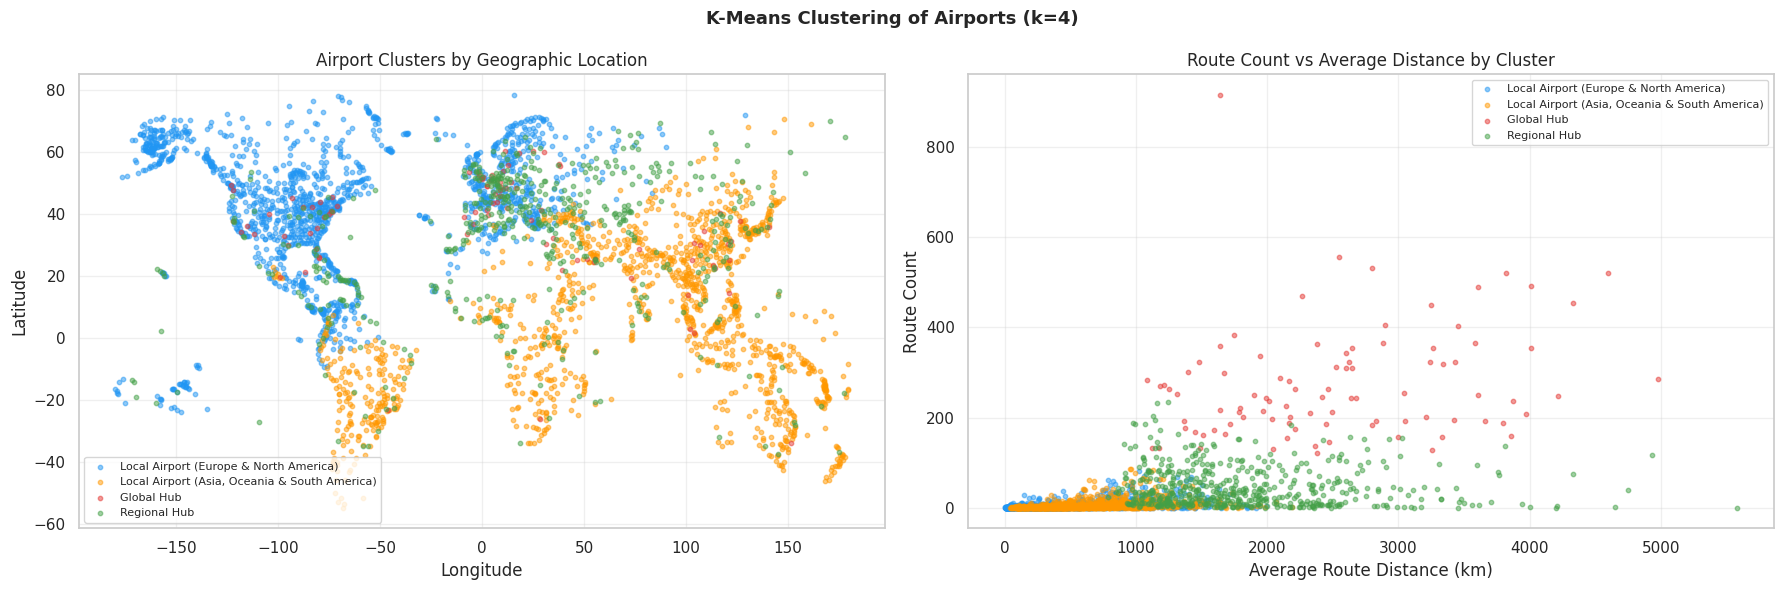

In [84]:
# ── Plot clusters on geographic map ──────────────────────────────────────
cluster_colors = {0: '#2196F3', 1: '#FF9800', 2: '#E53935', 3: '#43A047'}
cluster_labels = {
    0: 'Local Airport (Europe & North America)',
    1: 'Local Airport (Asia, Oceania & South America)',
    2: 'Global Hub',
    3: 'Regional Hub'
}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('K-Means Clustering of Airports (k=4)', fontsize=13, fontweight='bold')

# Panel 1 — Geographic scatter
ax1 = axes[0]
for cluster_id, group in airport_df.groupby('cluster'):
    ax1.scatter(group['lon'], group['lat'],
                c=cluster_colors[cluster_id],
                label=cluster_labels[cluster_id],
                alpha=0.5, s=10)
ax1.set_title('Airport Clusters by Geographic Location')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.legend(loc='lower left', fontsize=8)
ax1.grid(alpha=0.3)

# Panel 2 — Route count vs avg distance
ax2 = axes[1]
for cluster_id, group in airport_df.groupby('cluster'):
    ax2.scatter(group['avg_distance'], group['route_count'],
                c=cluster_colors[cluster_id],
                label=cluster_labels[cluster_id],
                alpha=0.5, s=10)
ax2.set_title('Route Count vs Average Distance by Cluster')
ax2.set_xlabel('Average Route Distance (km)')
ax2.set_ylabel('Route Count')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation of Results**

The geographic plot reveals that aviation infrastructure is not evenly
distributed across the world. **Global hubs** are tightly concentrated in
Europe, North America, and East Asia — regions with the highest economic
activity and travel demand. **Regional hubs** fill in the gaps across Africa,
the Middle East, and Southeast Asia. **Local airports**, despite being the most
numerous, are scattered across all continents with no dominant concentration,
reflecting that basic air connectivity exists widely but at a limited scale.

The route count vs average distance plot reinforces this hierarchy. Global
hubs stand out clearly in the upper right, combining high route counts with
long average distances. Regional hubs sit in the middle ground, while both
local airport clusters concentrate in the lower left with few routes and
short distances, confirming their limited operational scope.

## 5.3 Comparing Clusters with Actual Airport Types

To assess whether the K-Means clusters align with real-world airport
classifications, we plot the airports using their actual labeled types
from the dataset and compare them side by side with the cluster results.

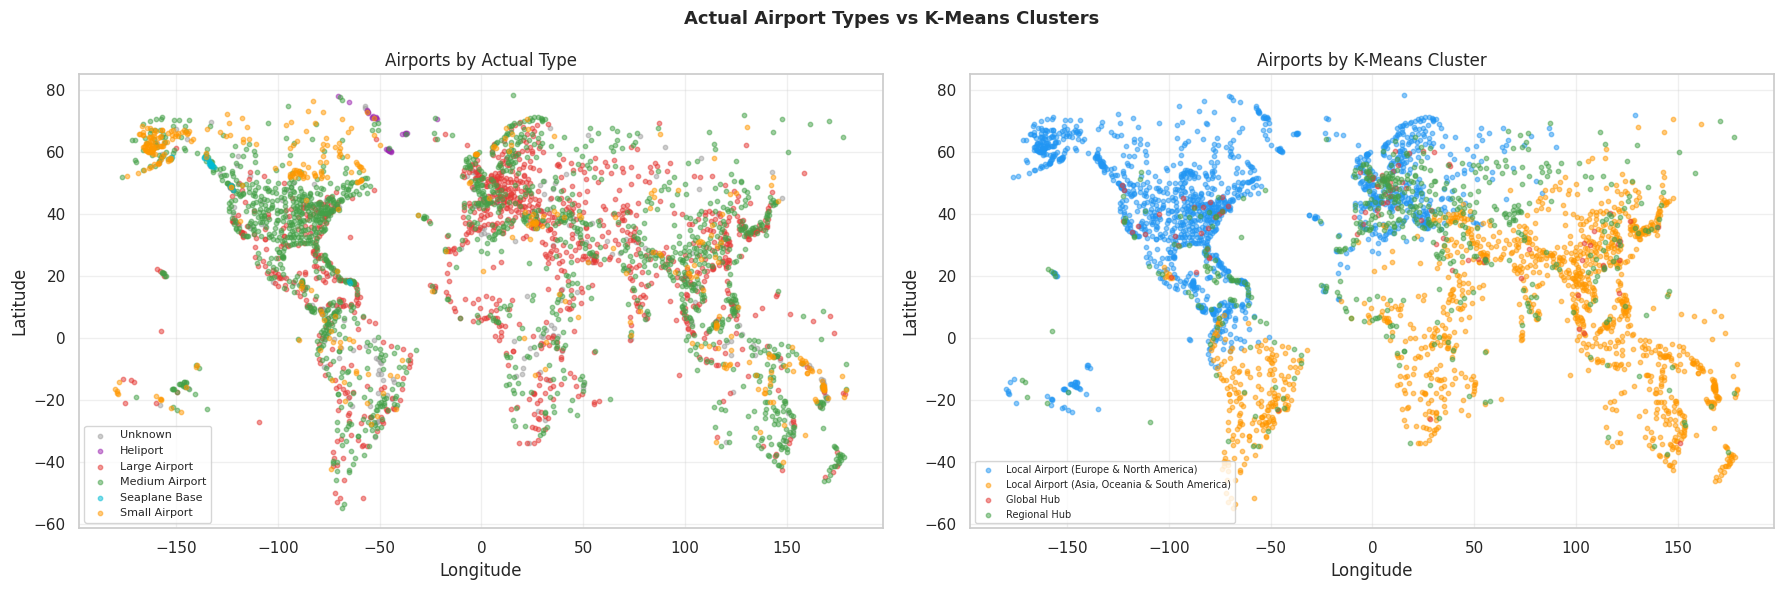

In [85]:
# ── Plot airports by actual labeled type ─────────────────────────────────
type_colors = {
    'large_airport'  : '#E53935',
    'medium_airport' : '#43A047',
    'small_airport'  : '#FF9800',
    'heliport'       : '#9C27B0',
    'seaplane_base'  : '#00BCD4',
    'Unknown'        : '#9E9E9E'
}

# Keep only airports in our clustered dataset
airport_plot = airport_df.copy()
airport_plot = airport_plot.merge(
    master_df[['src_iata', 'src_airport_type']].drop_duplicates(),
    on='src_iata', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Actual Airport Types vs K-Means Clusters',
             fontsize=13, fontweight='bold')

# Panel 1 — Actual airport types
ax1 = axes[0]
for atype, group in airport_plot.groupby('src_airport_type'):
    ax1.scatter(group['lon'], group['lat'],
                c=type_colors.get(atype, '#9E9E9E'),
                label=atype.replace('_', ' ').title(),
                alpha=0.5, s=10)
ax1.set_title('Airports by Actual Type')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.legend(loc='lower left', fontsize=8)
ax1.grid(alpha=0.3)

# Panel 2 — K-Means clusters (for direct comparison)
ax2 = axes[1]
for cluster_id, group in airport_df.groupby('cluster'):
    ax2.scatter(group['lon'], group['lat'],
                c=cluster_colors[cluster_id],
                label=cluster_labels[cluster_id],
                alpha=0.5, s=10)
ax2.set_title('Airports by K-Means Cluster')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.legend(loc='lower left', fontsize=7)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation of Results**

The comparison reveals an interesting finding. While global hubs identified
by K-Means do align with large airports in the labeled data, many large
airports are not classified as global hubs. This is visible in the left plot
where large airports (red) are spread widely across all continents, yet in
the right plot, many of those same locations appear as local or regional
clusters rather than global hubs. This suggests that being categorized as
a large airport does not automatically translate to high route capacity or
global connectivity.

This is an important distinction — the original dataset classifies airports
by physical infrastructure size, not by the volume of routes they operate.
A large airport in a smaller or less connected market may still serve a
limited number of routes, while a medium airport in a highly connected hub
city could outperform it in terms of connectivity. The K-Means clusters
capture this operational reality more accurately than the size label alone.

## Conclusion

In this section, we applied K-Means clustering to group airports resulting in four distinct groups — Global Hubs, Regional Hubs, and two Local Airport clusters separated by geographic location. Applying K-Means clustering to airports taught us that the global aviation network is far more unequal than it might appear. Without being given any labels, the algorithm naturally arrived at groupings that reflect real-world airport roles, and the fact that these clusters align with actual airport types confirms that operational characteristics alone are strong enough to define an airport's place in the global network. Most strikingly, just 92 airports drive 38.1% of all routes in the dataset.

The analysis also challenged the assumption that airport size determines
capacity. Many airports labeled as large did not make it into the global
hub cluster, suggesting that physical infrastructure and operational output
do not always go hand in hand. This is something that predefined labels alone would not have surfaced, and it demonstrates the value of unsupervised learning in uncovering structure that goes beyond what is explicitly recorded in the data.

# 6. Project Conclusion

## 6.1 Summary

This project set out to investigate global aviation through the lens of
physical infrastructure, asking whether features like airport elevation,
size, and geographic position could explain how the global flight network
is structured. Across five analytical methods — data exploration, regression,
model evaluation, supervised learning, and unsupervised learning — a
consistent picture emerged.

Elevation alone is a weak predictor of route distance, but it becomes
meaningful in geographic context. When latitude and longitude differences
are added, the MLR model explains 84.7% of route distance variance,
confirming that where an airport sits on the map matters far more than
how high it sits above sea level. This finding carried through into the
logistic regression and SVM models, both of which showed that geographic
and infrastructure features together are sufficient to classify route type
at around 72–74% accuracy — without any airline schedule or demand data.

The unsupervised learning section reinforced this by showing that airports
naturally organize into a clear hierarchy — global hubs, regional hubs, and
local airports — based on the same geographic and operational features.
Crucially, this hierarchy does not map neatly onto the predefined airport size labels in the dataset. Many large airports are not global hubs, and some medium
airports outperform large ones in route capacity. This was further supported
by the capacity analysis, which found that airport designation alone does not
determine operational output.

At the broadest level, the traffic dominance analysis showed that global
aviation is highly concentrated meaning that a small number of countries, airlines, and airports account for a disproportionate share of all routes. The United States and China dominate by route volume, routes within the same continent account for the highest traffic volumes, and just 92 airports drive 38.1% of all routes. Together, these findings suggest that global aviation is not structured by labels or designations, but by geography, demand, and the compounding advantages of already well-connected hubs.

## 6.2 Limitations

Several limitations should be acknowledged when interpreting the findings
of this project.

- The dataset reflects a static snapshot of global aviation routes and does
  not account for seasonal changes, flight frequency, or passenger volume.
  A route from New York to London and a route between two small islands both
  appear as one row each, even though the first might fly 10 times a day and
  the second once a week. This means we cannot measure how busy a route
  actually is.
- Both SVM and logistic regression use linear decision boundaries, which
  may not fully capture the complexity of the data, partly explaining why
  the models achieved 74% accuracy rather than higher. A more flexible model like Random Forest could potentially find patterns that a linear boundary misses.
- The K-Means clustering results are sensitive to the choice of k and the
  inclusion of geographic features. The four groups identified are one valid
  interpretation of the data, but different choices of k or features could
  lead to a different grouping entirely.

## 6.3 Directions for Future Research

- Incorporating flight frequency and passenger volume data would allow
  the analysis to move beyond route existence and measure actual traffic
  intensity, giving a more accurate picture of airport capacity and
  connectivity.

- Applying non-linear classifiers such as Random Forest or Gradient
  Boosting to the route type classification task could improve on the
  74% accuracy achieved by the linear SVM.

- Experimenting with a feature set that separates geographic and operational
  dimensions in the clustering analysis could provide a cleaner understanding
  of whether airport roles are driven more by location or by operational scale.

- A time-series analysis tracking how airport connectivity has changed over
  the years could reveal whether the dominance of major hubs is growing or
  whether regional aviation markets are becoming more competitive.

- The weak effect of elevation on route distance raises an interesting question
  that this project could not answer — is elevation irrelevant because geography simply dominates as a predictor, or has modern aircraft technology advanced to the point where high-altitude operations no longer impose meaningful constraints on route planning? Incorporating aircraft type and operational performance data into future analysis could help disentangle these two explanations.